<a href="https://colab.research.google.com/github/Bivasgithub/Sea_Breeze_Front/blob/main/Trend_Sea_Breeze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

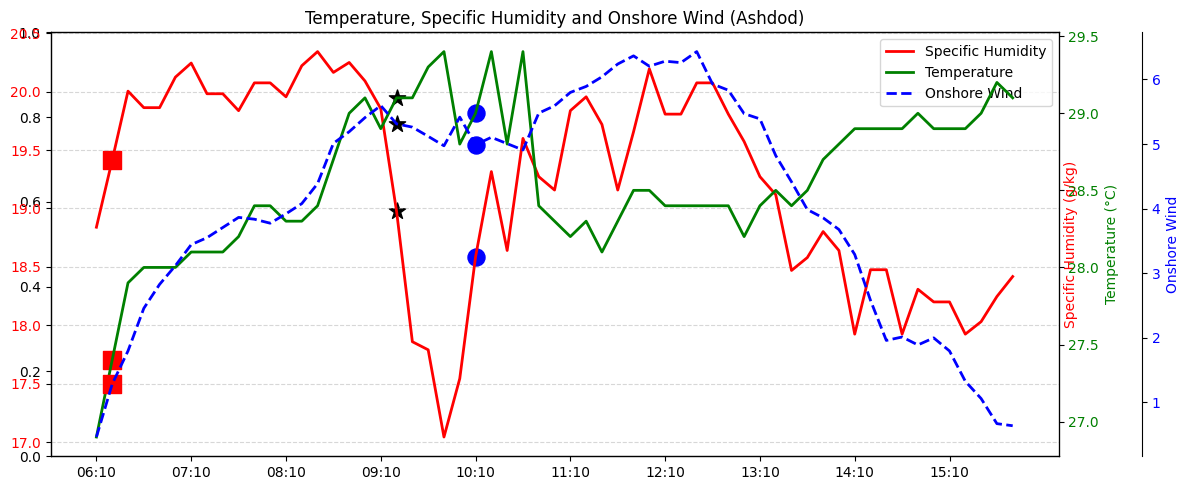

In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_trend(file_path):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces & Convert numeric columns
    df.columns = df.columns.str.strip()
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # Filter required date and time
    df = df[
        (df.index.year == 2025) &
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # Wind components
    theta = np.deg2rad(
        df["Wind direction (°)"].values
    )
    V = df["Wind speed (m/s)"].values
    # Meteorological wind components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v
    # Coastline orientation angle
    alpha = np.deg2rad(100)
    # Onshore wind component
    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # Specific humidity
    T_K = df["Temperature (°C)"] + 273.15
    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )
    # Convert to g/kg
    df["q_gkg"] = df["q"] * 1000

    # Function to compute 3-point slope
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        # x coordinates
        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):
            y = np.array([
                values[i - 1],
                values[i],
                values[i + 1]
            ])

            # Best-fit line slope
            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)

        return slopes

    # Compute 3-point moving trends
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    # Optional rounding
    trend_cols = [
        "Temp_3point_slope",
        "q_3point_slope",
        "Vonshore_3point_slope"
    ]

    df[trend_cols] = df[trend_cols].round(4)
    df = df.dropna() # Only 2 NaN values
    #df = df.fillna(df.mean(numeric_only=True)) # If not to remove


    # Find t1: where V_onshore > 0
    mask_u_positive = df["V_onshore"] > 0
    t1 = (
        df.loc[mask_u_positive, "q_3point_slope"]
        .abs()
        .idxmax()
    )

    # t2: where: q_3point_slope > 0 & V_onshore > 0
    mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))

    t2 = (df.loc[mask_t2, "q_3point_slope"].idxmax())

    # t3: where: Largest positive Vonshore_3point_slope & V_onshore > 0
    t3 = (df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax())

    # Store times in dataframe
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True


    return df

# Example usage

#file_path = "/content/Jova_data.xlsx"
file_path = "/content/Ashdod_data.xlsx"

result = compute_sbf_trend(file_path)


import matplotlib.pyplot as plt

def plot_combined_sbf_slopes(df):
    fig, ax1 = plt.subplots(figsize=(12, 5))

# Specific humidity slope
    ax1 = ax1.twinx()
    ax1.plot(df.index, df["q_gkg"], color="red", linewidth=2,
        label="Specific Humidity")
    ax1.set_ylabel("Specific Humidity (g/kg)", color="red")
    ax1.tick_params( axis='y', labelcolor="red")

# Temperature slope
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["Temperature (°C)"], color="green", linewidth=2,
        label="Temperature")
    ax2.set_ylabel("Temperature (°C)", color="green")
    ax2.tick_params(
        axis='y',
        labelcolor="green"
    )

    # Onshore wind slope
    ax3 = ax1.twinx()
    # Move third axis outward
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(df.index, df["V_onshore"], color="blue", linestyle="--",
        linewidth=2,
        label="Onshore Wind"
    )
    ax3.set_ylabel("Onshore Wind", color="blue")
    ax3.tick_params(axis='y', labelcolor="blue")

    # t1 Peak points
    t1_row = result[result["t1"]]
    ax1.scatter(t1_row.index, t1_row["q_gkg"], marker="*", color="black", s=150)
    ax2.scatter(t1_row.index, t1_row["Temperature (°C)"], marker="*", color="black", s=150)
    ax3.scatter(t1_row.index, t1_row["V_onshore"], marker="*", color="black", s=150)

    # t2 Peak points
    t2_row = result[result["t2"]]
    ax1.scatter(t2_row.index, t2_row["q_gkg"], marker="o", color="blue", s=150)
    ax2.scatter(t2_row.index, t2_row["Temperature (°C)"], marker="o", color="blue", s=150)
    ax3.scatter(t2_row.index, t2_row["V_onshore"], marker="o", color="blue", s=150)

    #t3 peak points
    t3_row = result[result["t3"]]
    ax1.scatter(t3_row.index, t3_row["q_gkg"], marker="s", color="red", s=150)
    ax2.scatter(t3_row.index, t3_row["Temperature (°C)"], marker="s", color="red", s=150)
    ax3.scatter(t3_row.index, t3_row["V_onshore"], marker="s", color="red", s=150)


    # X-axis formatting
    ax1.set_xlabel("Time (UTC)")
    ax1.set_xticks(df.index[::6])
    ax1.set_xticklabels(
        df.index[::6].strftime("%H:%M"),
        rotation=45
    )

    #plt.xlabel("Time (UTC)")
    plt.title("Temperature, Specific Humidity and Onshore Wind (Ashdod)")

    # Combined legend
    lines = (
        ax1.get_lines()
        + ax2.get_lines()
        + ax3.get_lines()
    )

    labels = [l.get_label() for l in lines]

    ax1.legend(
        lines,
        labels,
        loc="best"
    )

    ax1.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    # lines.append(ax1.collections[0])
    # ax1.legend(lines, labels, loc="best")

    # Layout and save
    plt.tight_layout()
    plt.savefig(
        "SBF_3point_trends.jpg",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# Call the function
plot_combined_sbf_slopes(result)


# **Combination of 5 subplots**

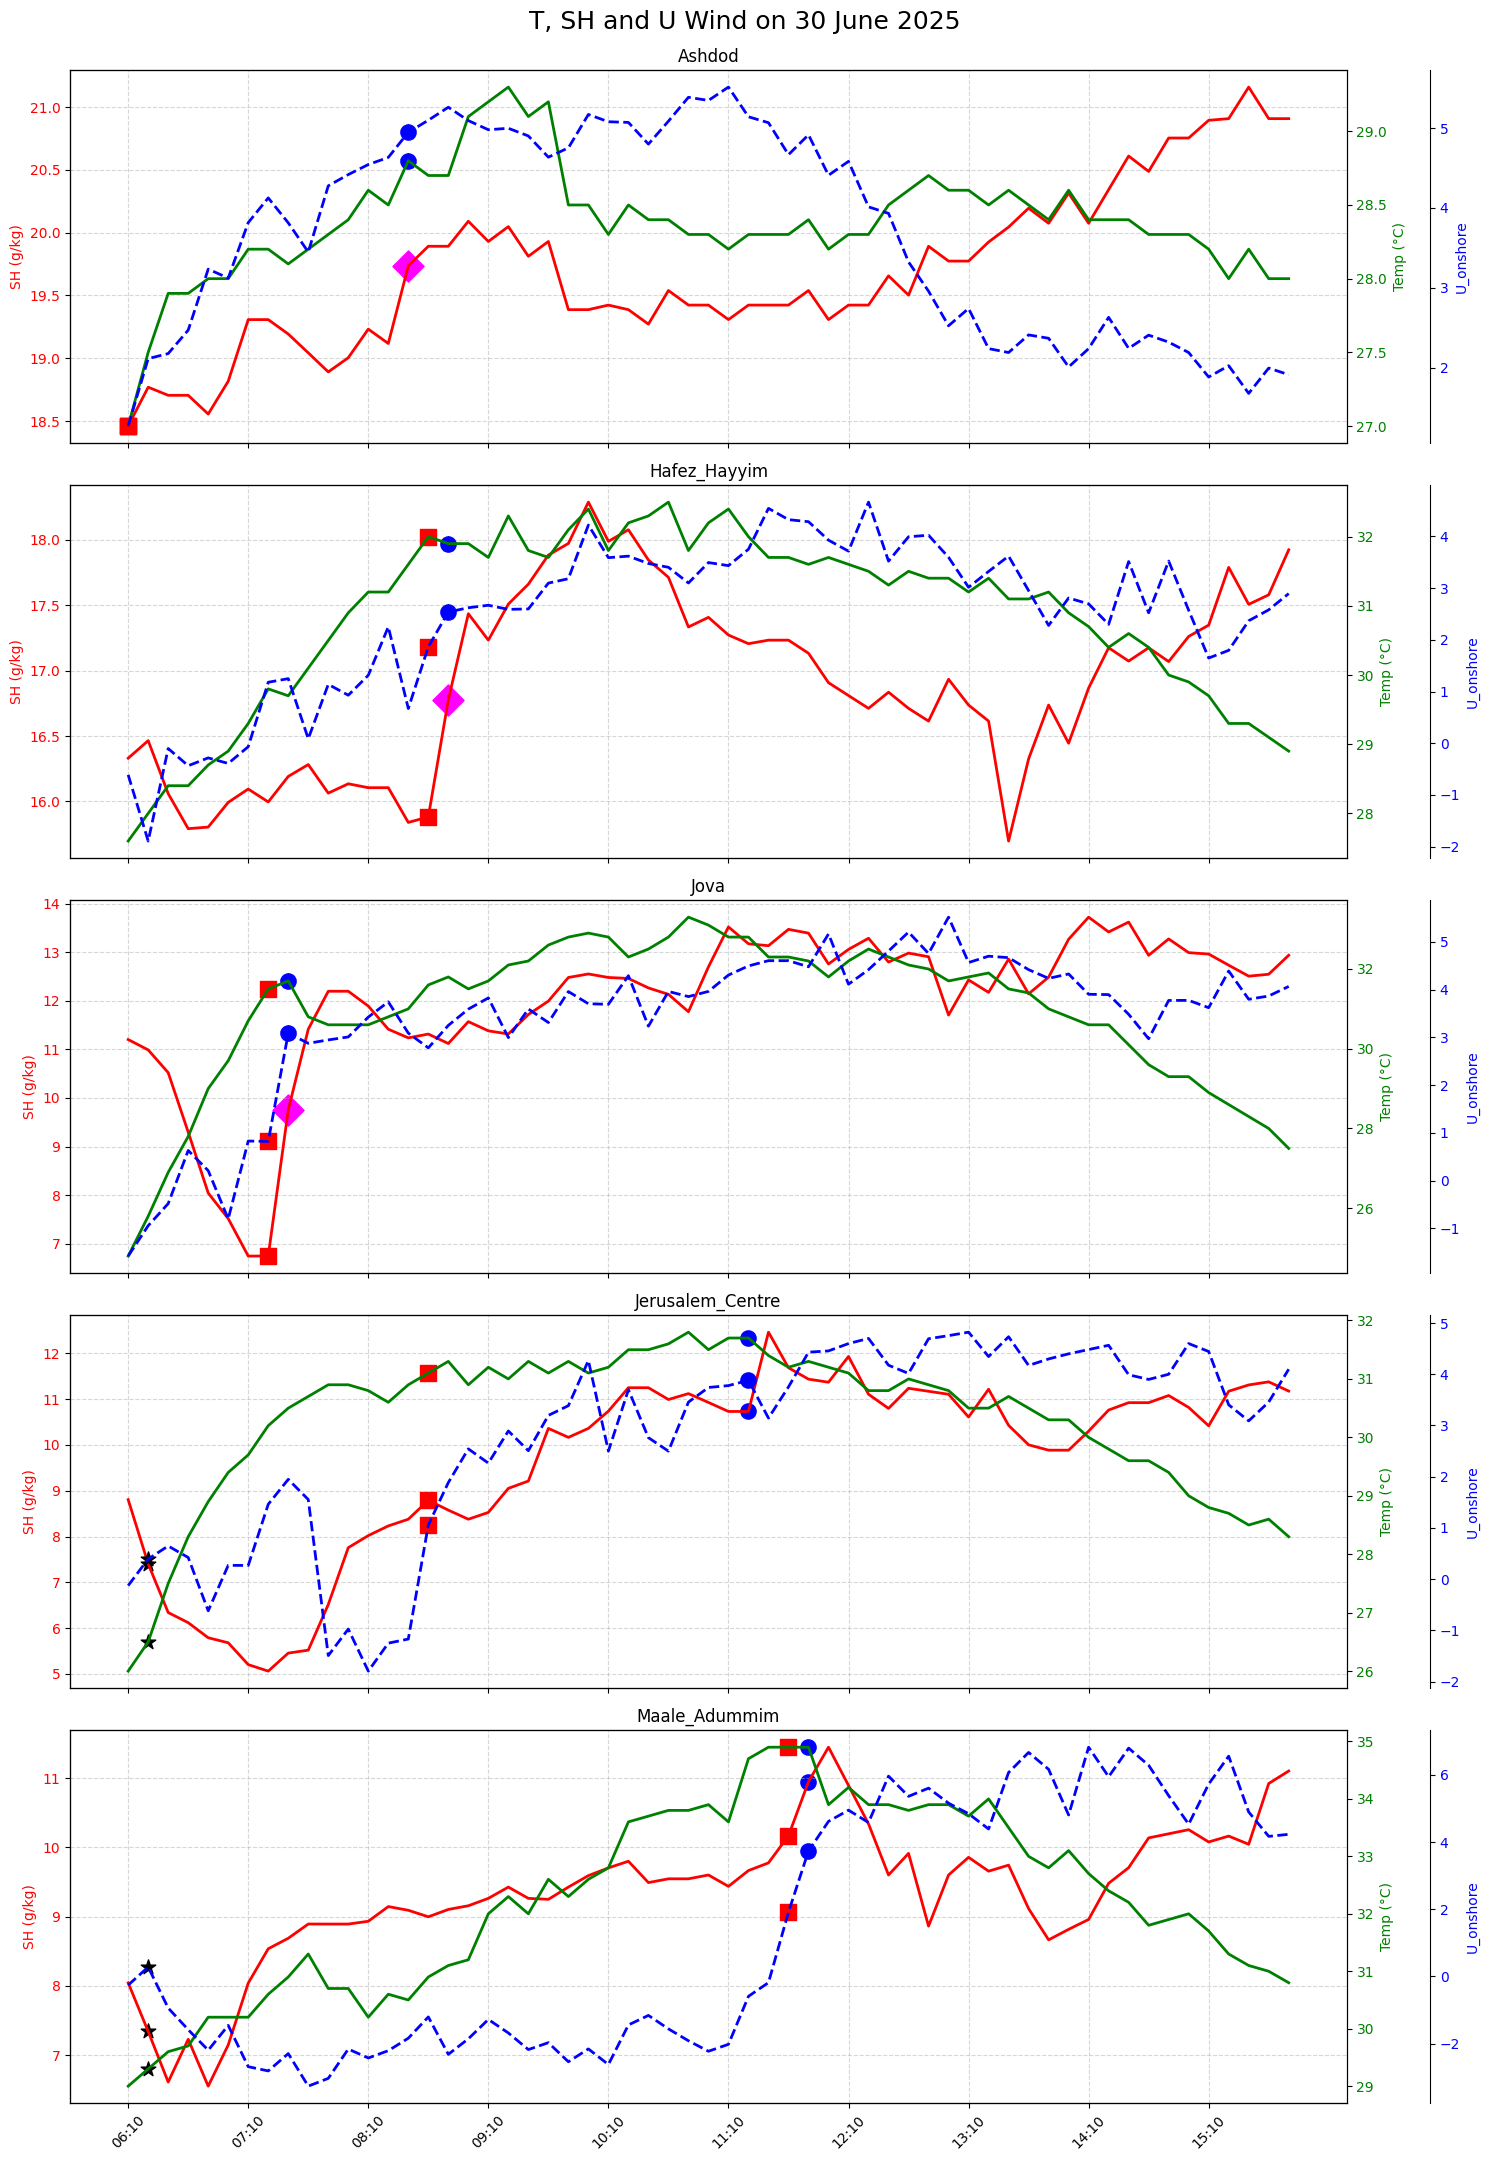

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to compute t1, t2 & t3
def compute_sbf_trend(file_path):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()
    # Convert numeric columns
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)

    # Filter date and time
    df = df[
        (df.index.year == 2025) &
        (df.index.month == 6) &
        (df.index.day == 30)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    alpha = np.deg2rad(100)
    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100 / 100.0)* (R / Rv)* (A / p)* np.exp(-B / T_K))

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE FUNCTION

    def moving_slope(series):
        values = series.values
        slopes = [np.nan]

        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([values[i - 1], values[i], values[i + 1]])
            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)
        return slopes

    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0
    t1 = (
        df.loc[mask_u_positive,
               "q_3point_slope"]
        .abs()
        .idxmax()
    )

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        &
        (df["V_onshore"] > 0)
    )

    t2 = (
        df.loc[mask_t2,
               "q_3point_slope"]
        .idxmax()
    )

    t3 = (
        df.loc[mask_u_positive,
               "Vonshore_3point_slope"]
        .idxmax()
    )

    # Store flags
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True

    return df


# FILES FOR 5 STATIONS
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

# COMPUTE RESULTS
results = {}
for station, file in station_files.items():
    results[station] = compute_sbf_trend(file)

# PLOT ALL 5 STATIONS
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(15, 22),
    sharex=True
)

for ax, (station, df) in zip(axes, results.items()):

    # Axis 1 → Specific Humidity
    ax.plot(
        df.index,
        df["q_gkg"],
        color="red",
        linewidth=2,
        label="Specific Humidity"
    )

    ax.set_ylabel(
        "SH (g/kg)",
        color="red"
    )

    ax.tick_params(
        axis='y',
        labelcolor="red"
    )

     # Axis 2 → Temperature
    ax2 = ax.twinx()
    ax2.plot(
        df.index,
        df["Temperature (°C)"],
        color="green",
        linewidth=2,
        label="Temperature"
    )

    ax2.set_ylabel(
        "Temp (°C)",
        color="green"
    )

    ax2.tick_params(
        axis='y',
        labelcolor="green"
    )

    # Axis 3 → Onshore Wind
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(
        ("outward", 60)
    )

    ax3.plot(
        df.index,
        df["V_onshore"],
        color="blue",
        linestyle="--",
        linewidth=2,
        label="Onshore Wind"
    )

    ax3.set_ylabel(
        "U_onshore",
        color="blue"
    )

    ax3.tick_params(
        axis='y',
        labelcolor="blue"
    )

    # t1 markers

    t1_row = df[df["t1"]]
    ax.scatter(
        t1_row.index,
        t1_row["q_gkg"],
        marker="*",
        s=120,
        color="black"
    )

    ax2.scatter(
        t1_row.index,
        t1_row["Temperature (°C)"],
        marker="*",
        s=120,
        color="black"
    )

    ax3.scatter(
        t1_row.index,
        t1_row["V_onshore"],
        marker="*",
        s=120,
        color="black"
    )

    # t2 markers
    t2_row = df[df["t2"]]
    ax.scatter(
        t2_row.index,
        t2_row["q_gkg"],
        marker="o",
        s=120,
        color="blue"
    )

    ax2.scatter(
        t2_row.index,
        t2_row["Temperature (°C)"],
        marker="o",
        s=120,
        color="blue"
    )

    ax3.scatter(
        t2_row.index,
        t2_row["V_onshore"],
        marker="o",
        s=120,
        color="blue"
    )

    # t3 markers
    t3_row = df[df["t3"]]
    ax.scatter(
        t3_row.index,
        t3_row["q_gkg"],
        marker="s",
        s=120,
        color="red"
    )

    ax2.scatter(
        t3_row.index,
        t3_row["Temperature (°C)"],
        marker="s",
        s=120,
        color="red"
    )

    ax3.scatter(
        t3_row.index,
        t3_row["V_onshore"],
        marker="s",
        s=120,
        color="red"
    )


    # Overlap points
    df["overlap_count"] = (df[["t1", "t2", "t3"]].sum(axis=1))

    overlap = df[df["overlap_count"] > 1]
    overlap_scatter = ax.scatter(
    overlap.index,
    overlap["q_gkg"],
    marker="D",
    color="magenta",
    s=250,
    label="Overlap")



    # Formatting
    ax.set_title(station)

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    ax.set_xticks(df.index[::6])

    ax.set_xticklabels(
        df.index[::6].strftime("%H:%M"),
        rotation=45
    )

# FIGURE TITLE
fig.suptitle(
    "T, SH and U Wind on 30 June 2025\n", fontsize=18)

plt.tight_layout()

plt.savefig(
    "All_Stations_SBF.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# **Finding the 3-point moving trend for V_onshore, Specific Humidity and Temperature Gradient.**

In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_trend(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()
    df.columns = df.columns.str.strip()

    # Convert numeric columns
    for col in [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # Filter data
    df = df[
        (df.index.year == 2024) &
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # Onshore wind component
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    # Wind components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    # Coastline orientation angle
    alpha = np.deg2rad(100)
    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # Specific humidity
    T_K = df["Temperature (°C)"] + 273.15
    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"] / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000  # g/kg


    # 3-point slope function
    def slope_3pt(y):
        # Time axis in minutes
        x = np.array([0, 10, 20])
        # Linear regression slope
        m = np.polyfit(x, y, 1)[0]

        return m

    # 3-point moving trend slopes
    # Temperature trend
    df["dT_s"] = (
        df["Temperature (°C)"]
        .rolling(window=3, center=True)
        .apply(slope_3pt, raw=True)
    )

    # Specific humidity trend
    df["dq_s"] = (
        df["q_gkg"]
        .rolling(window=3, center=True)
        .apply(slope_3pt, raw=True)
    )

    # Onshore wind trend
    df["V_s"] = (
        df["V_onshore"]
        .rolling(window=3, center=True)
        .apply(slope_3pt, raw=True)
    )

    #df = df.dropna()

    return df

#file_path = "/content/Jova_data.xlsx"
file_path = "/content/Jerusalem_Centre_data.xlsx"

df_result = compute_sbf_trend(file_path)

# **Checking on 17th June data and indicators**

In [1]:
import pandas as pd
import numpy as np

# Read Excel file
df = pd.read_excel("/content/Jerusalem_Centre_data.xlsx", engine="openpyxl")
df = df[[
    "Date & Time (UTC)",
    "Wind speed (m/s)",
    "Wind direction (°)",
    "Relative humidity (%)",
    "Temperature (°C)"
    ]].copy()

# Remove extra spaces & Convert numeric columns
df.columns = df.columns.str.strip()
numeric_cols = [
    "Wind speed (m/s)",
    "Wind direction (°)",
    "Relative humidity (%)",
    "Temperature (°C)"
    ]

for col in numeric_cols:
  df[col] = pd.to_numeric(df[col], errors="coerce")

# Datetime handling
df["Date & Time (UTC)"] = pd.to_datetime(
    df["Date & Time (UTC)"], dayfirst=True)

df.set_index("Date & Time (UTC)", inplace=True)

# Filter required date and time
df = df[
    (df.index.year == 2025) &
    (df.index.month == 5) &
    (df.index.day == 17)
    ].between_time("06:00", "16:00")

In [26]:
# WIND COMPONENTS
theta = np.deg2rad(df["Wind direction (°)"].values)
V = df["Wind speed (m/s)"].values
u = -V * np.sin(theta)
v = -V * np.cos(theta)
df["u"] = u
df["v"] = v
alpha = np.deg2rad(100)
df["V_onshore"] = (df["u"] * np.sin(alpha) + df["v"] * np.cos(alpha))

# SPECIFIC HUMIDITY
T_K = df["Temperature (°C)"] + 273.15
A = 2.53e7
B = 5420
R = 287
Rv = 461
p = 920

df["q"] = ((df["Relative humidity (%)"]*100 / 100.0)* (R / Rv)* (A / p)* np.exp(-B / T_K))
df["q_gkg"] = df["q"] * 1000

# MOVING SLOPE FUNCTION
def moving_slope(series):
    values = series.values
    slopes = [np.nan]
    x = np.array([0, 1, 2])
    for i in range(1, len(values) - 1):
        y = np.array([
            values[i - 1],
            values[i],
            values[i + 1]
        ])
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
    slopes.append(np.nan)
    return slopes

# COMPUTE SLOPES
df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
df["q_3point_slope"] = moving_slope(df["q_gkg"])
df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
df = df.dropna()

# t1, t2, t3
mask_u_positive = df["V_onshore"] > 0
t1 = (df.loc[mask_u_positive,"q_3point_slope"].abs().idxmax())

mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))

#t2 = (df.loc[mask_t2, "q_3point_slope"].idxmax())

mask_t2 = (
    (df["q_3point_slope"] > 0)
    &
    (df["V_onshore"] > 0)
)

if mask_t2.any():

    t2 = df.loc[
        mask_t2,
        "q_3point_slope"
    ].idxmax()

else:

    t2 = t1

t3 = (df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax())

# Store flags
df["t1"] = False
df["t2"] = False
df["t3"] = False

df.loc[t1, "t1"] = True
df.loc[t2, "t2"] = True
df.loc[t3, "t3"] = True

/tmp/ipykernel_6039/3111884905.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["t1"] = False
/tmp/ipykernel_6039/3111884905.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["t2"] = False
/tmp/ipykernel_6039/3111884905.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

In [30]:
#print(df.head())
print(df["t2"].value_counts())
#print(t3)

t2
False    44
True      1
Name: count, dtype: int64


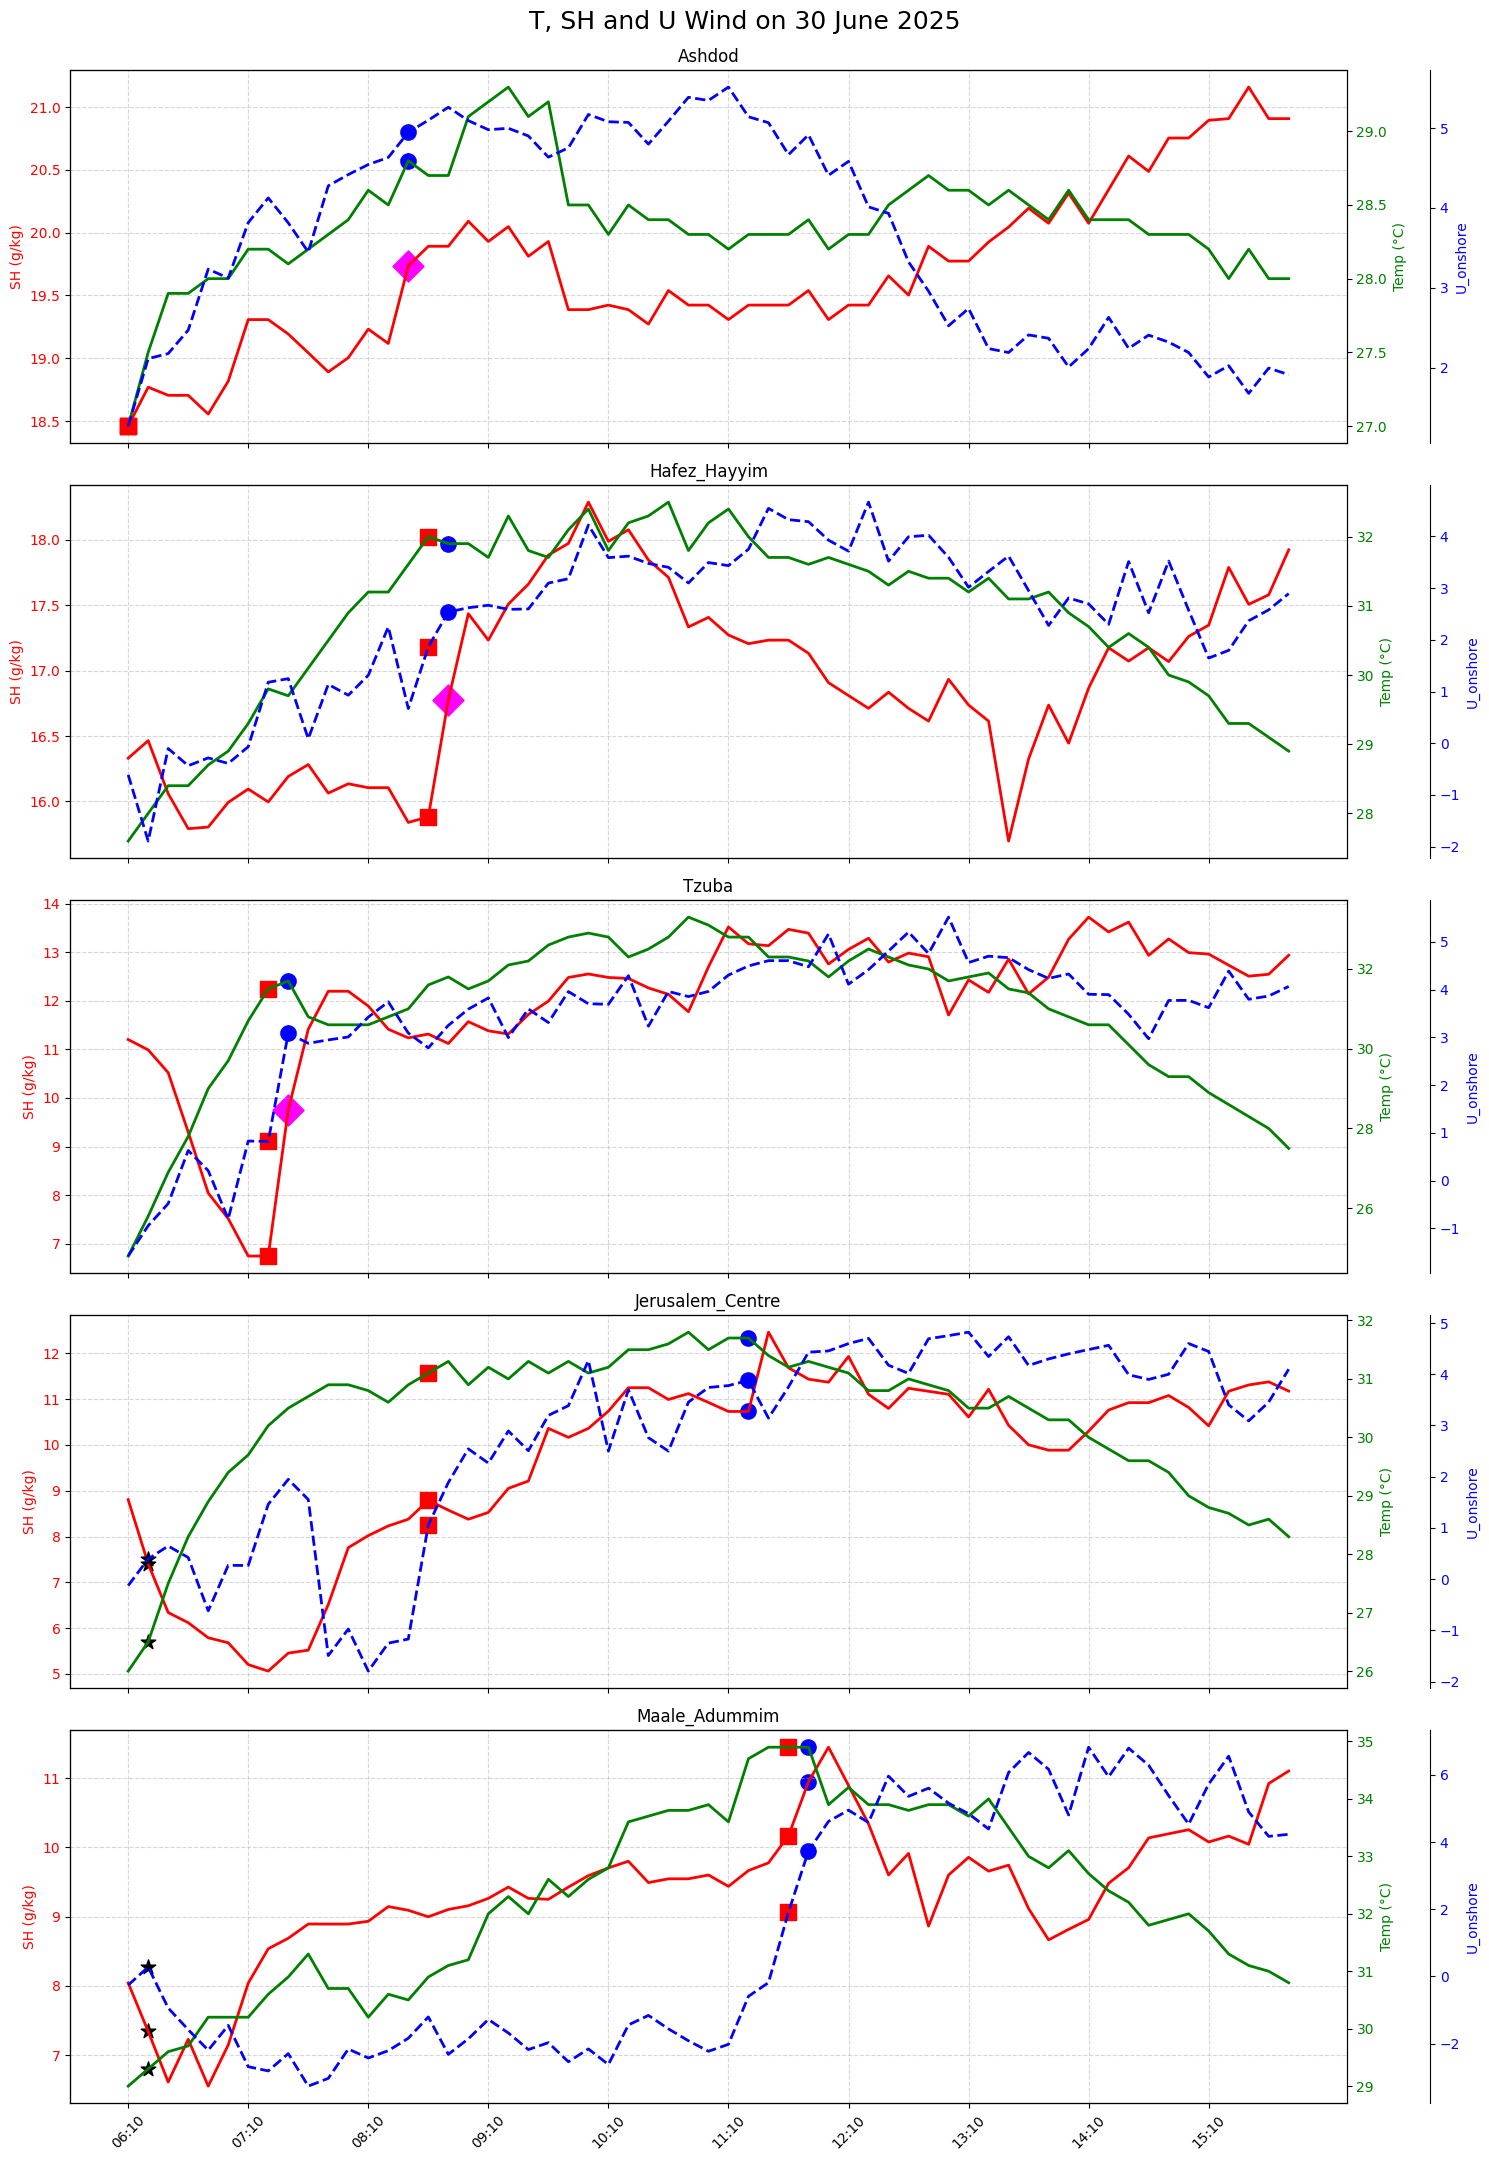

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to compute t1, t2 & t3
def compute_sbf_trend(file_path):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()
    # Convert numeric columns
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)

    # Filter date and time
    df = df[
        (df.index.year == 2025) &
        (df.index.month == 6) &
        (df.index.day == 30)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    alpha = np.deg2rad(100)
    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100 / 100.0)* (R / Rv)* (A / p)* np.exp(-B / T_K))

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE FUNCTION

    def moving_slope(series):
        values = series.values
        slopes = [np.nan]

        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([values[i - 1], values[i], values[i + 1]])
            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)
        return slopes

    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0
    t1 = (
        df.loc[mask_u_positive,
               "q_3point_slope"]
        .abs()
        .idxmax()
    )

    # mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))
    # t2 = (df.loc[mask_t2, "q_3point_slope"].idxmax())

    mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))
    if mask_t2.any():
      t2 = df.loc[mask_t2, "q_3point_slope"].idxmax()
    else:
      t2 = t1

    t3 = (df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax())

    # Store flags
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True

    return df


# FILES FOR 5 STATIONS
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

# COMPUTE RESULTS
results = {}
for station, file in station_files.items():
    results[station] = compute_sbf_trend(file)

# PLOT ALL 5 STATIONS
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(15, 22),
    sharex=True
)

for ax, (station, df) in zip(axes, results.items()):

    # Axis 1 → Specific Humidity
    ax.plot(
        df.index,
        df["q_gkg"],
        color="red",
        linewidth=2,
        label="Specific Humidity"
    )

    ax.set_ylabel(
        "SH (g/kg)",
        color="red"
    )

    ax.tick_params(
        axis='y',
        labelcolor="red"
    )

     # Axis 2 → Temperature
    ax2 = ax.twinx()
    ax2.plot(
        df.index,
        df["Temperature (°C)"],
        color="green",
        linewidth=2,
        label="Temperature"
    )

    ax2.set_ylabel(
        "Temp (°C)",
        color="green"
    )

    ax2.tick_params(
        axis='y',
        labelcolor="green"
    )

    # Axis 3 → Onshore Wind
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(
        ("outward", 60)
    )

    ax3.plot(
        df.index,
        df["V_onshore"],
        color="blue",
        linestyle="--",
        linewidth=2,
        label="Onshore Wind"
    )

    ax3.set_ylabel(
        "U_onshore",
        color="blue"
    )

    ax3.tick_params(
        axis='y',
        labelcolor="blue"
    )

    # t1 markers

    t1_row = df[df["t1"]]
    ax.scatter(
        t1_row.index,
        t1_row["q_gkg"],
        marker="*",
        s=120,
        color="black"
    )

    ax2.scatter(
        t1_row.index,
        t1_row["Temperature (°C)"],
        marker="*",
        s=120,
        color="black"
    )

    ax3.scatter(
        t1_row.index,
        t1_row["V_onshore"],
        marker="*",
        s=120,
        color="black"
    )

    # t2 markers
    t2_row = df[df["t2"]]
    ax.scatter(
        t2_row.index,
        t2_row["q_gkg"],
        marker="o",
        s=120,
        color="blue"
    )

    ax2.scatter(
        t2_row.index,
        t2_row["Temperature (°C)"],
        marker="o",
        s=120,
        color="blue"
    )

    ax3.scatter(
        t2_row.index,
        t2_row["V_onshore"],
        marker="o",
        s=120,
        color="blue"
    )

    # t3 markers
    t3_row = df[df["t3"]]
    ax.scatter(
        t3_row.index,
        t3_row["q_gkg"],
        marker="s",
        s=120,
        color="red"
    )

    ax2.scatter(
        t3_row.index,
        t3_row["Temperature (°C)"],
        marker="s",
        s=120,
        color="red"
    )

    ax3.scatter(
        t3_row.index,
        t3_row["V_onshore"],
        marker="s",
        s=120,
        color="red"
    )


    # Overlap points
    df["overlap_count"] = (df[["t1", "t2", "t3"]].sum(axis=1))

    overlap = df[df["overlap_count"] > 1]
    overlap_scatter = ax.scatter(
    overlap.index,
    overlap["q_gkg"],
    marker="D",
    color="magenta",
    s=250,
    label="Overlap")



    # Formatting
    ax.set_title(station)

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    ax.set_xticks(df.index[::6])

    ax.set_xticklabels(
        df.index[::6].strftime("%H:%M"),
        rotation=45
    )

# FIGURE TITLE
fig.suptitle(
    "T, SH and U Wind on 30 June 2025\n", fontsize=18)

plt.tight_layout()

plt.savefig(
    "All_Stations_SBF.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [4]:
print(df[df.isna().any(axis=1)])

Empty DataFrame
Columns: [Wind speed (m/s), Wind direction (°), Relative humidity (%), Temperature (°C), u, v, V_onshore, q, q_gkg]
Index: []


# **Code only for 17th May, 2025**

# **Working on the code**

In [32]:
#print(result.head())

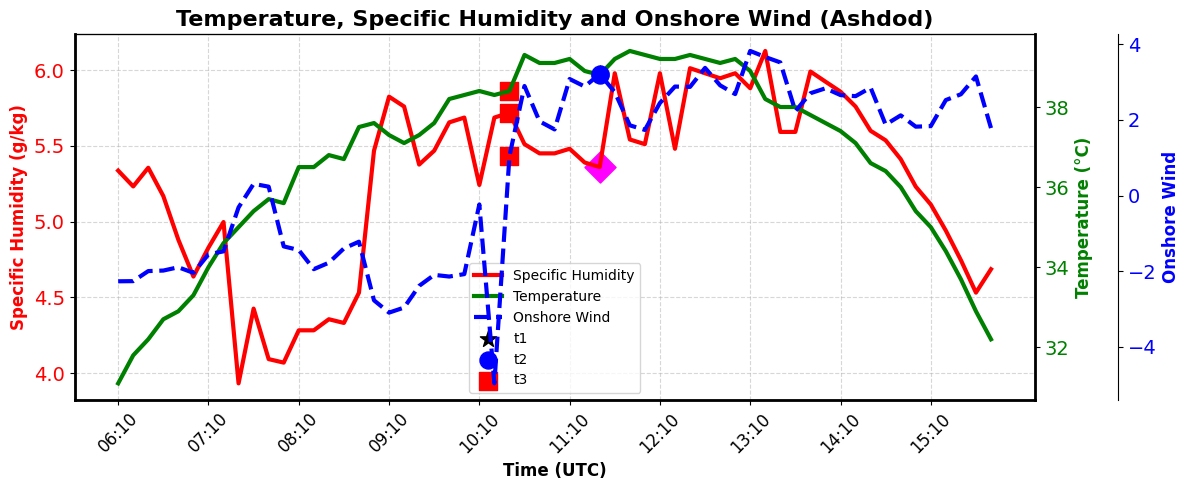

In [ ]:
import matplotlib.pyplot as plt


def plot_combined_sbf_slopes(df):

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Specific humidity
    ax1.plot(
        df.index,
        df["q_gkg"],
        color="red",
        linewidth=3,
        label="Specific Humidity")

    ax1.set_ylabel("Specific Humidity (g/kg)", color="red", fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor="red", labelsize=14)

    # Temperature axis
    ax2 = ax1.twinx()

    ax2.plot(
        df.index,
        df["Temperature (°C)"],
        color="green",
        linewidth=3,
        label="Temperature")

    ax2.set_ylabel("Temperature (°C)", color="green", fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor="green", labelsize=14)


    # Onshore wind axis
    ax3 = ax1.twinx()

    # Move third axis outward
    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        df.index,
        df["V_onshore"],
        color="blue",
        linestyle="--",
        linewidth=3,
        label="Onshore Wind")

    ax3.set_ylabel("Onshore Wind", color="blue", fontsize=12, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor="blue", labelsize=14)

    # t1 points
    t1_row = df[df["t1"]]

    t1_scatter = ax1.scatter(
        t1_row.index,
        t1_row["q_gkg"],
        marker="*",
        color="black",
        s=150,
        label="t1"
    )

    ax2.scatter(
        t1_row.index,
        t1_row["Temperature (°C)"],
        marker="*",
        color="black",
        s=150
    )

    ax3.scatter(
        t1_row.index,
        t1_row["V_onshore"],
        marker="*",
        color="black",
        s=150
    )

    # t2 points
    t2_row = df[df["t2"]]

    t2_scatter = ax1.scatter(
        t2_row.index,
        t2_row["q_gkg"],
        marker="o",
        color="blue",
        s=150,
        label="t2"
    )

    ax2.scatter(
        t2_row.index,
        t2_row["Temperature (°C)"],
        marker="o",
        color="blue",
        s=150
    )

    ax3.scatter(
        t2_row.index,
        t2_row["V_onshore"],
        marker="o",
        color="blue",
        s=150
    )

    # t3 points
    t3_row = df[df["t3"]]

    t3_scatter = ax1.scatter(
        t3_row.index,
        t3_row["q_gkg"],
        marker="s",
        color="red",
        s=150,
        label="t3"
    )

    ax2.scatter(
        t3_row.index,
        t3_row["Temperature (°C)"],
        marker="s",
        color="red",
        s=150
    )

    ax3.scatter(
        t3_row.index,
        t3_row["V_onshore"],
        marker="s",
        color="red",
        s=150
    )


    # Overlap points
    df["overlap_count"] = (
        df[["t1", "t2", "t3"]].sum(axis=1))

    overlap = df[df["overlap_count"] > 1]
    overlap_scatter = ax1.scatter(
    overlap.index,
    overlap["q_gkg"],
    marker="D",
    color="magenta",
    s=250,
    label="Overlap")

    # X-axis formatting
    ax1.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
    ax1.set_xticks(df.index[::6])
    ax1.set_xticklabels(df.index[::6].strftime("%H:%M"),
                        rotation=45, fontsize= 12)

    # Title
    plt.title("Temperature, Specific Humidity and Onshore Wind (Ashdod)",
              fontsize=16, fontweight='bold')

    # Combined legend
    lines = (
        ax1.get_lines()
        + ax2.get_lines()
        + ax3.get_lines()
    )

    labels = [l.get_label() for l in lines]

    # Add scatter handles
    lines.extend([
        t1_scatter,
        t2_scatter,
        t3_scatter
    ])

    labels.extend([
        "t1",
        "t2",
        "t3"
    ])

    ax1.legend(
        lines,
        labels,
        loc="best"
    )

    # Grid
    ax1.grid(
        True,
        linestyle="--",
        alpha=0.5
    )


    ax1.spines["bottom"].set_linewidth(2)
    ax1.spines["left"].set_linewidth(2)
    ax1.spines["right"].set_linewidth(2)
    #ax3.spines["left"].set_linewidth(3)

    # Layout and save
    plt.tight_layout()

    plt.savefig(
        "SBF_3point_trends.jpg",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# Call function
plot_combined_sbf_slopes(result)

# **Plots for different dates using a loop:**

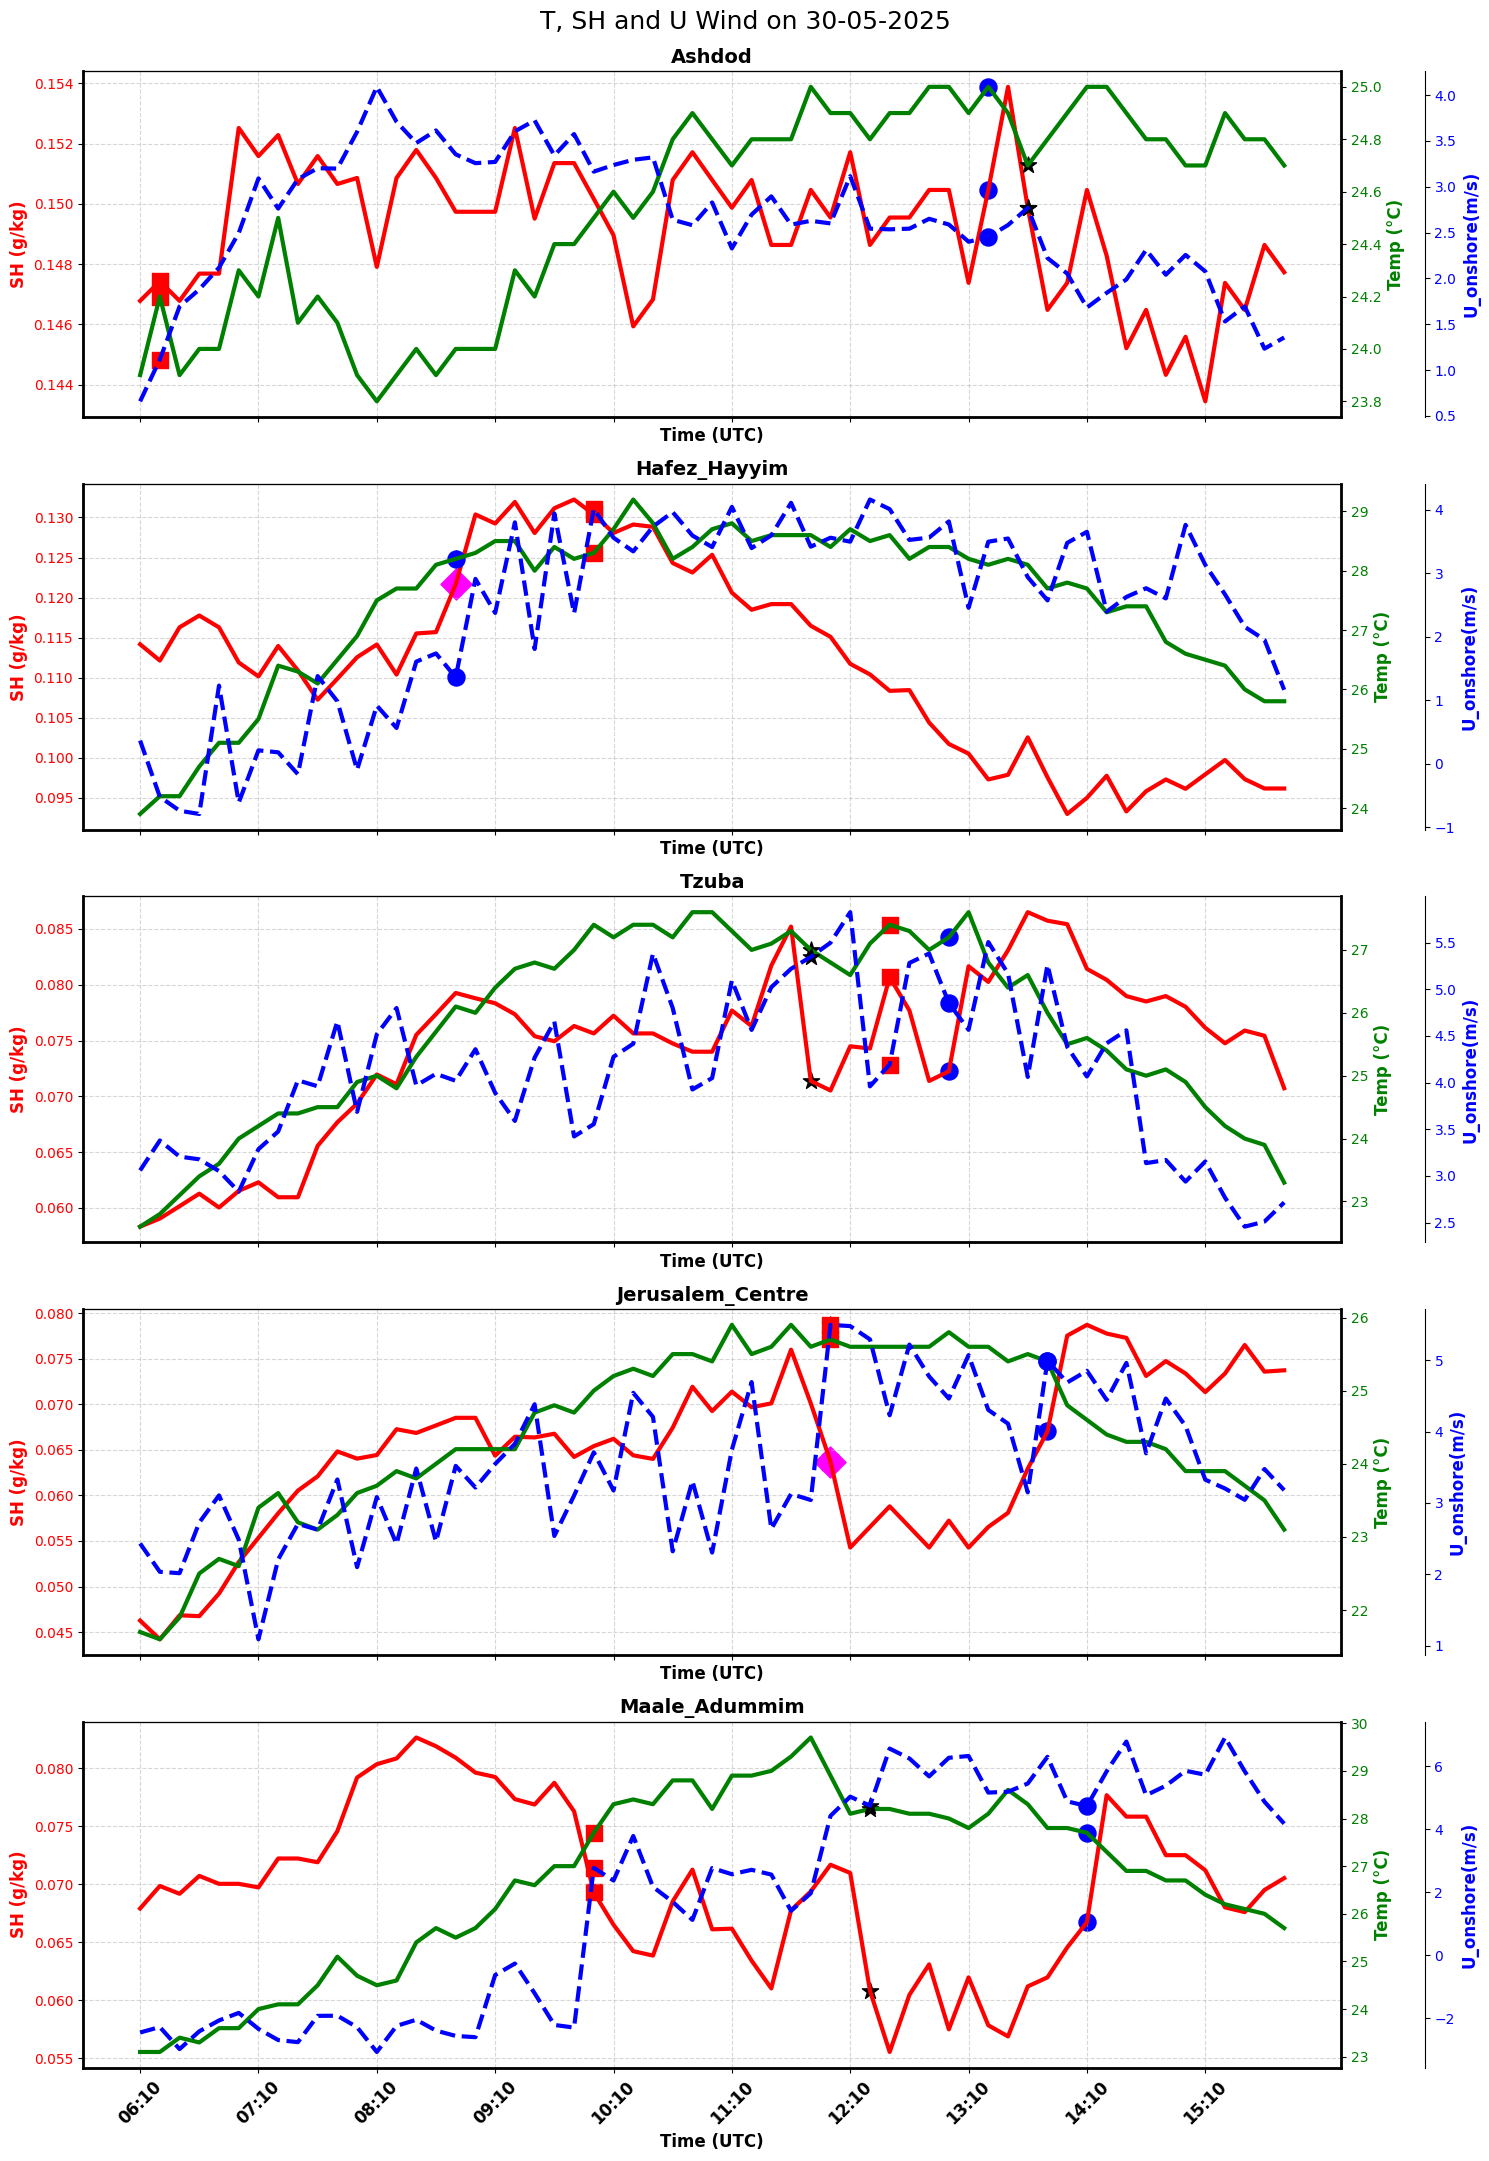

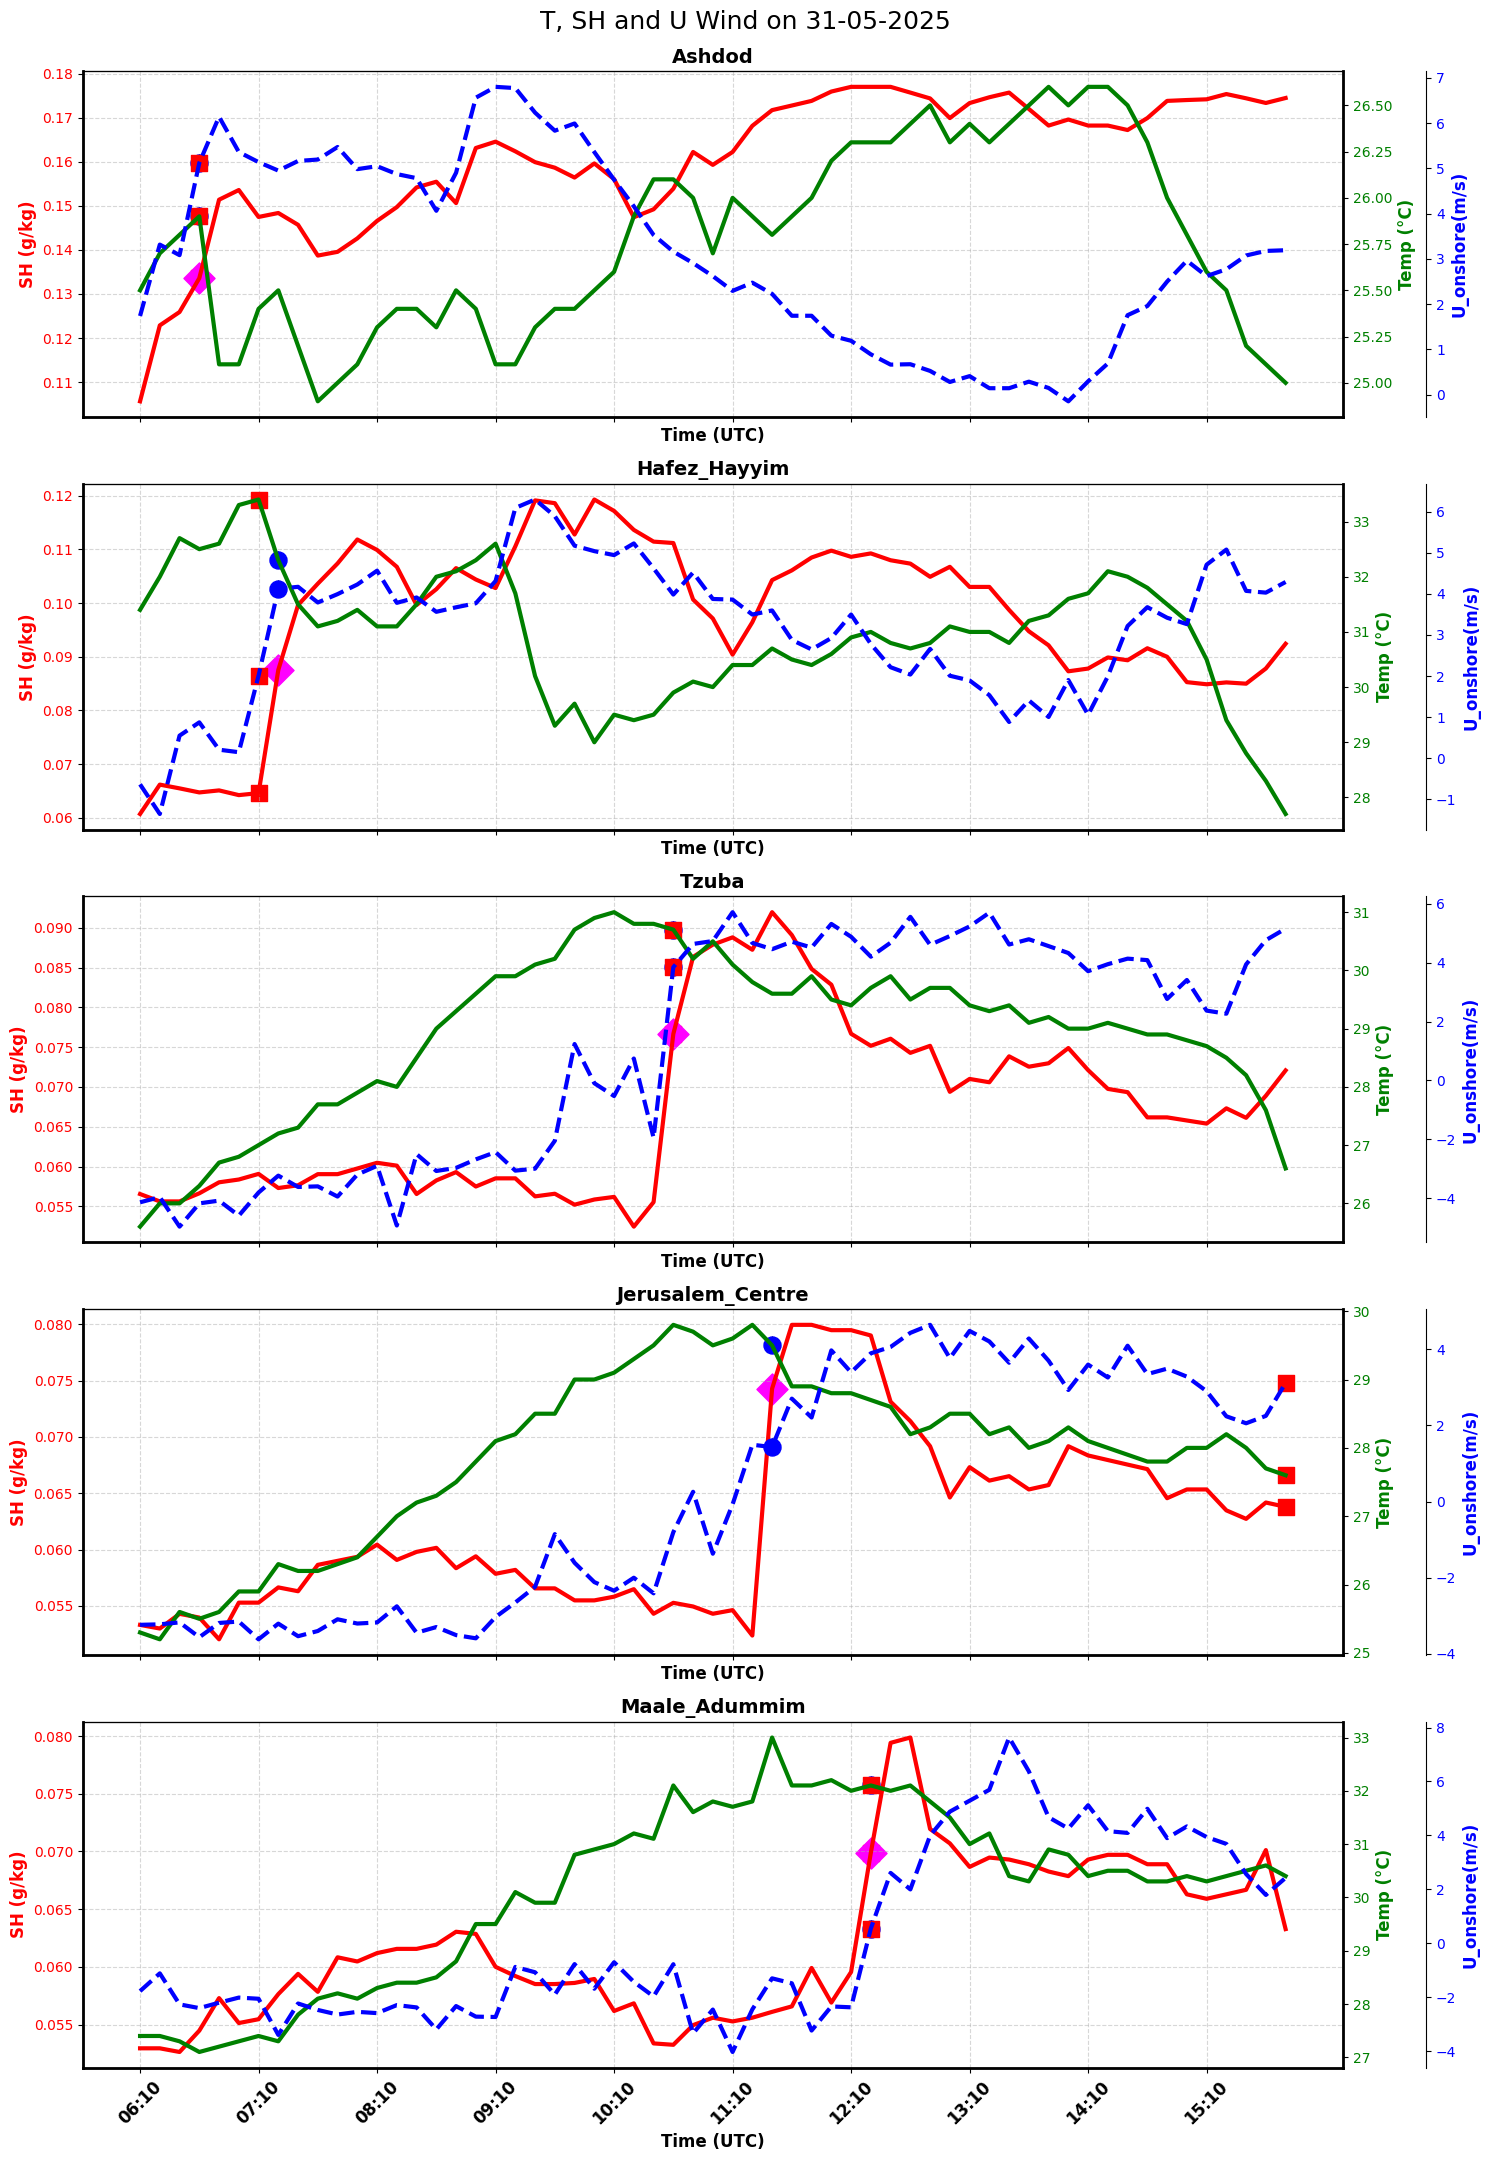

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3
def compute_sbf_trend(file_path, year, month, day):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()

    # Convert numeric columns
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DATE
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)

    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15

    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"] / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE FUNCTION
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([
                values[i - 1],
                values[i],
                values[i + 1]
            ])

            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)
        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    t1 = (
        df.loc[
            mask_u_positive,
            "q_3point_slope"
        ]
        .abs()
        .idxmax()
    )

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        &
        (df["V_onshore"] > 0)
    )

    t2 = (
        df.loc[
            mask_t2,
            "q_3point_slope"
        ]
        .idxmax()
    )

    t3 = (
        df.loc[
            mask_u_positive,
            "Vonshore_3point_slope"
        ]
        .idxmax()
    )

    # STORE FLAGS
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True

    return df


# FILES FOR 5 STATIONS
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# SELECT 7 CONSECUTIVE DAYS
dates = pd.date_range(start="2025-05-30", periods=2, freq="D")

# LOOP OVER DAYS
for current_date in dates:
    year = current_date.year
    month = current_date.month
    day = current_date.day

    # COMPUTE RESULTS
    results = {}
    for station, file in station_files.items():
        results[station] = compute_sbf_trend(file, year, month, day)

    # CREATE FIGURE
    fig, axes = plt.subplots(
        nrows=5,
        ncols=1,
        figsize=(15, 22),
        sharex=True
    )

    # PLOT ALL STATIONS
    for ax, (station, df) in zip(axes, results.items()):

        # Axis 1 → Specific Humidity
        ax.plot(df.index, df["q_gkg"], color="red", linewidth=3, label="Specific Humidity")
        ax.set_ylabel("SH (g/kg)", color="red", fontsize=12, fontweight='bold')
        ax.tick_params(axis='y', labelcolor="red")


        # Axis 2 → Temperature
        ax2 = ax.twinx()
        ax2.plot(df.index, df["Temperature (°C)"],
                 color="green", linewidth=3, label="Temperature")
        ax2.set_ylabel("Temp (°C)", color="green", fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor="green")

        # Axis 3 → Onshore Wind
        ax3 = ax.twinx()
        ax3.spines["right"].set_position(
            ("outward", 60)
        )

        ax3.plot(
            df.index,
            df["V_onshore"],
            color="blue",
            linestyle="--",
            linewidth=3,
            label="Onshore Wind"
        )

        ax3.set_ylabel("U_onshore(m/s)", color="blue", fontsize=12, fontweight='bold')
        ax3.tick_params(axis='y', labelcolor="blue")

        # t1 markers
        t1_row = df[df["t1"]]
        ax.scatter(
            t1_row.index,
            t1_row["q_gkg"],
            marker="*",
            s=150,
            color="black"
        )

        ax2.scatter(
            t1_row.index,
            t1_row["Temperature (°C)"],
            marker="*",
            s=150,
            color="black"
        )

        ax3.scatter(
            t1_row.index,
            t1_row["V_onshore"],
            marker="*",
            s=150,
            color="black"
        )

        # t2 markers
        t2_row = df[df["t2"]]
        ax.scatter(
            t2_row.index,
            t2_row["q_gkg"],
            marker="o",
            s=150,
            color="blue"
        )

        ax2.scatter(
            t2_row.index,
            t2_row["Temperature (°C)"],
            marker="o",
            s=150,
            color="blue"
        )

        ax3.scatter(
            t2_row.index,
            t2_row["V_onshore"],
            marker="o",
            s=150,
            color="blue"
        )

        # t3 markers
        t3_row = df[df["t3"]]
        ax.scatter(
            t3_row.index,
            t3_row["q_gkg"],
            marker="s",
            s=120,
            color="red"
        )

        ax2.scatter(
            t3_row.index,
            t3_row["Temperature (°C)"],
            marker="s",
            s=120,
            color="red"
        )

        ax3.scatter(
            t3_row.index,
            t3_row["V_onshore"],
            marker="s",
            s=120,
            color="red"
        )

        # Overlap points
        df["overlap_count"] = (
            df[["t1", "t2", "t3"]]
            .sum(axis=1)
        )

        overlap = df[df["overlap_count"] > 1]

        ax.scatter(
            overlap.index,
            overlap["q_gkg"],
            marker="D",
            color="magenta",
            s=250
        )

        # X-axis formatting
        ax.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
        ax.set_xticks(df.index[::6])
        ax.set_xticklabels(df.index[::6].strftime("%H:%M"),
                           rotation=45, fontsize= 12, fontweight='bold')
        # Formatting
        ax.set_title(station, fontsize=14, fontweight="bold")

        ax.grid(
            True,
            linestyle="--",
            alpha=0.5
        )

        # To increase axis length
        ax.spines["bottom"].set_linewidth(2)
        ax.spines["left"].set_linewidth(2)
        ax.spines["right"].set_linewidth(2)

        ax.set_xticks(df.index[::6])
        ax.set_xticklabels(df.index[::6].strftime("%H:%M"), rotation=45)

    # FIGURE TITLE
    fig.suptitle(
        f"T, SH and U Wind on {day:02d}-{month:02d}-{year}\n",
        fontsize=18
    )
    plt.tight_layout()

    # SAVE FIGURE
    plt.savefig(
        f"All_Stations_SBF_{year}_{month:02d}_{day:02d}.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [ ]:
#print(result.head(5))
print(result.isnull().sum(axis=0))

Wind speed (m/s)         0
Wind direction (°)       0
Relative humidity (%)    0
Temperature (°C)         0
u                        0
v                        0
V_onshore                0
q                        0
q_gkg                    0
Temp_3point_slope        2
q_3point_slope           2
Vonshore_3point_slope    2
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_trend(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    for col in ["Wind speed (m/s)", "Wind direction (°)", "Relative humidity (%)", "Temperature (°C)"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # df = df[
    #     (df.index.month == 6) &
    #     (df.index.day == 28)
    # ].between_time("06:00", "16:00")

    # For 2_year 2nd dataset
    df = df[
        (df.index.year == 2024) &
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "16:00")

    # Temperature gradient
    df = df.dropna()
    df["dT"] = df["Temperature (°C)"].diff()

## Onshore component of Wind Speed
    # Now apply deg2rad
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    # # Compute components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    alpha = np.deg2rad(100) # (Consider 90+10 degree)

    df["V_onshore"] = (df["u"] * np.sin(alpha)
    + df["v"] * np.cos(alpha))
    #df["V_onshore"] = u

    # Compute specific humidity
    T_K = df["Temperature (°C)"] + 273.15
    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (df["Relative humidity (%)"]*100.0 / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df["q_gkg"] = df["q"] * 1000 # gm/kg
    # Specific humidity tendency
    df["dq"] = df["q_gkg"].diff()

#### Working on it
    #df["dW"] = df["Wind speed (m/s)"].diff()
    df["dT_n"] = (df["dT"] - df["dT"].mean()) / df["dT"].std()
    df["dq_n"] = (df["dq"] - df["dq"].mean()) / df["dq"].std()
    df["V_n"] = (df["V_onshore"] - df["V_onshore"].mean()) / df["V_onshore"].std()

    # Weighted SBF_index
    df["SBF_index"] = 0.40*df["V_n"] + 0.35*df["dq_n"] - 0.25*df["dT_n"]

    # 99th percentile threshold
    threshold = df["SBF_index"].quantile(0.98)

    # Filtering conditions
    df["SBF_flag"] = (
        (df["SBF_index"] > threshold) &
        (df["V_onshore"] > 0) &   # +ve Onshore component
        (df["dT"] < 0)      # temperature drop
    )

    df["SBF_peak"] = (
        (df["SBF_index"] > df["SBF_index"].shift(1)) &
        (df["SBF_index"] > df["SBF_index"].shift(-1)) &
        (df["SBF_flag"])
    )

    df = df.dropna()

    return df, threshold


#file_path = "/content/Jova_data.xlsx"
file_path = "/content/Ashdod_data.xlsx"

df_result, threshold = compute_sbf_trend(file_path)

print("\n :: Sea Breeze Front Candidates :: \n")
print(df_result[df_result["SBF_flag"]][[
    "Temperature (°C)", "q_gkg", "V_onshore", "SBF_index"
]])

print("\n ::Peak Front Arrival Time:: \n")
print(df_result[df_result["SBF_peak"]].index)


 :: Sea Breeze Front Candidates :: 

Empty DataFrame
Columns: [Temperature (°C), q_gkg, V_onshore, SBF_index]
Index: []

 ::Peak Front Arrival Time:: 

DatetimeIndex([], dtype='datetime64[ns]', name='Date & Time (UTC)', freq=None)


In [ ]:
print(df_result.head())

Empty DataFrame
Columns: [Wind speed (m/s), Wind direction (°), Relative humidity (%), Temperature (°C), dT, u, v, V_onshore, q, q_gkg, dq, dT_n, dq_n, V_n, SBF_index, SBF_flag, SBF_peak]
Index: []


In [ ]:
#print(df_result.head())

# **Final code by haldling the condition if t2 not True**

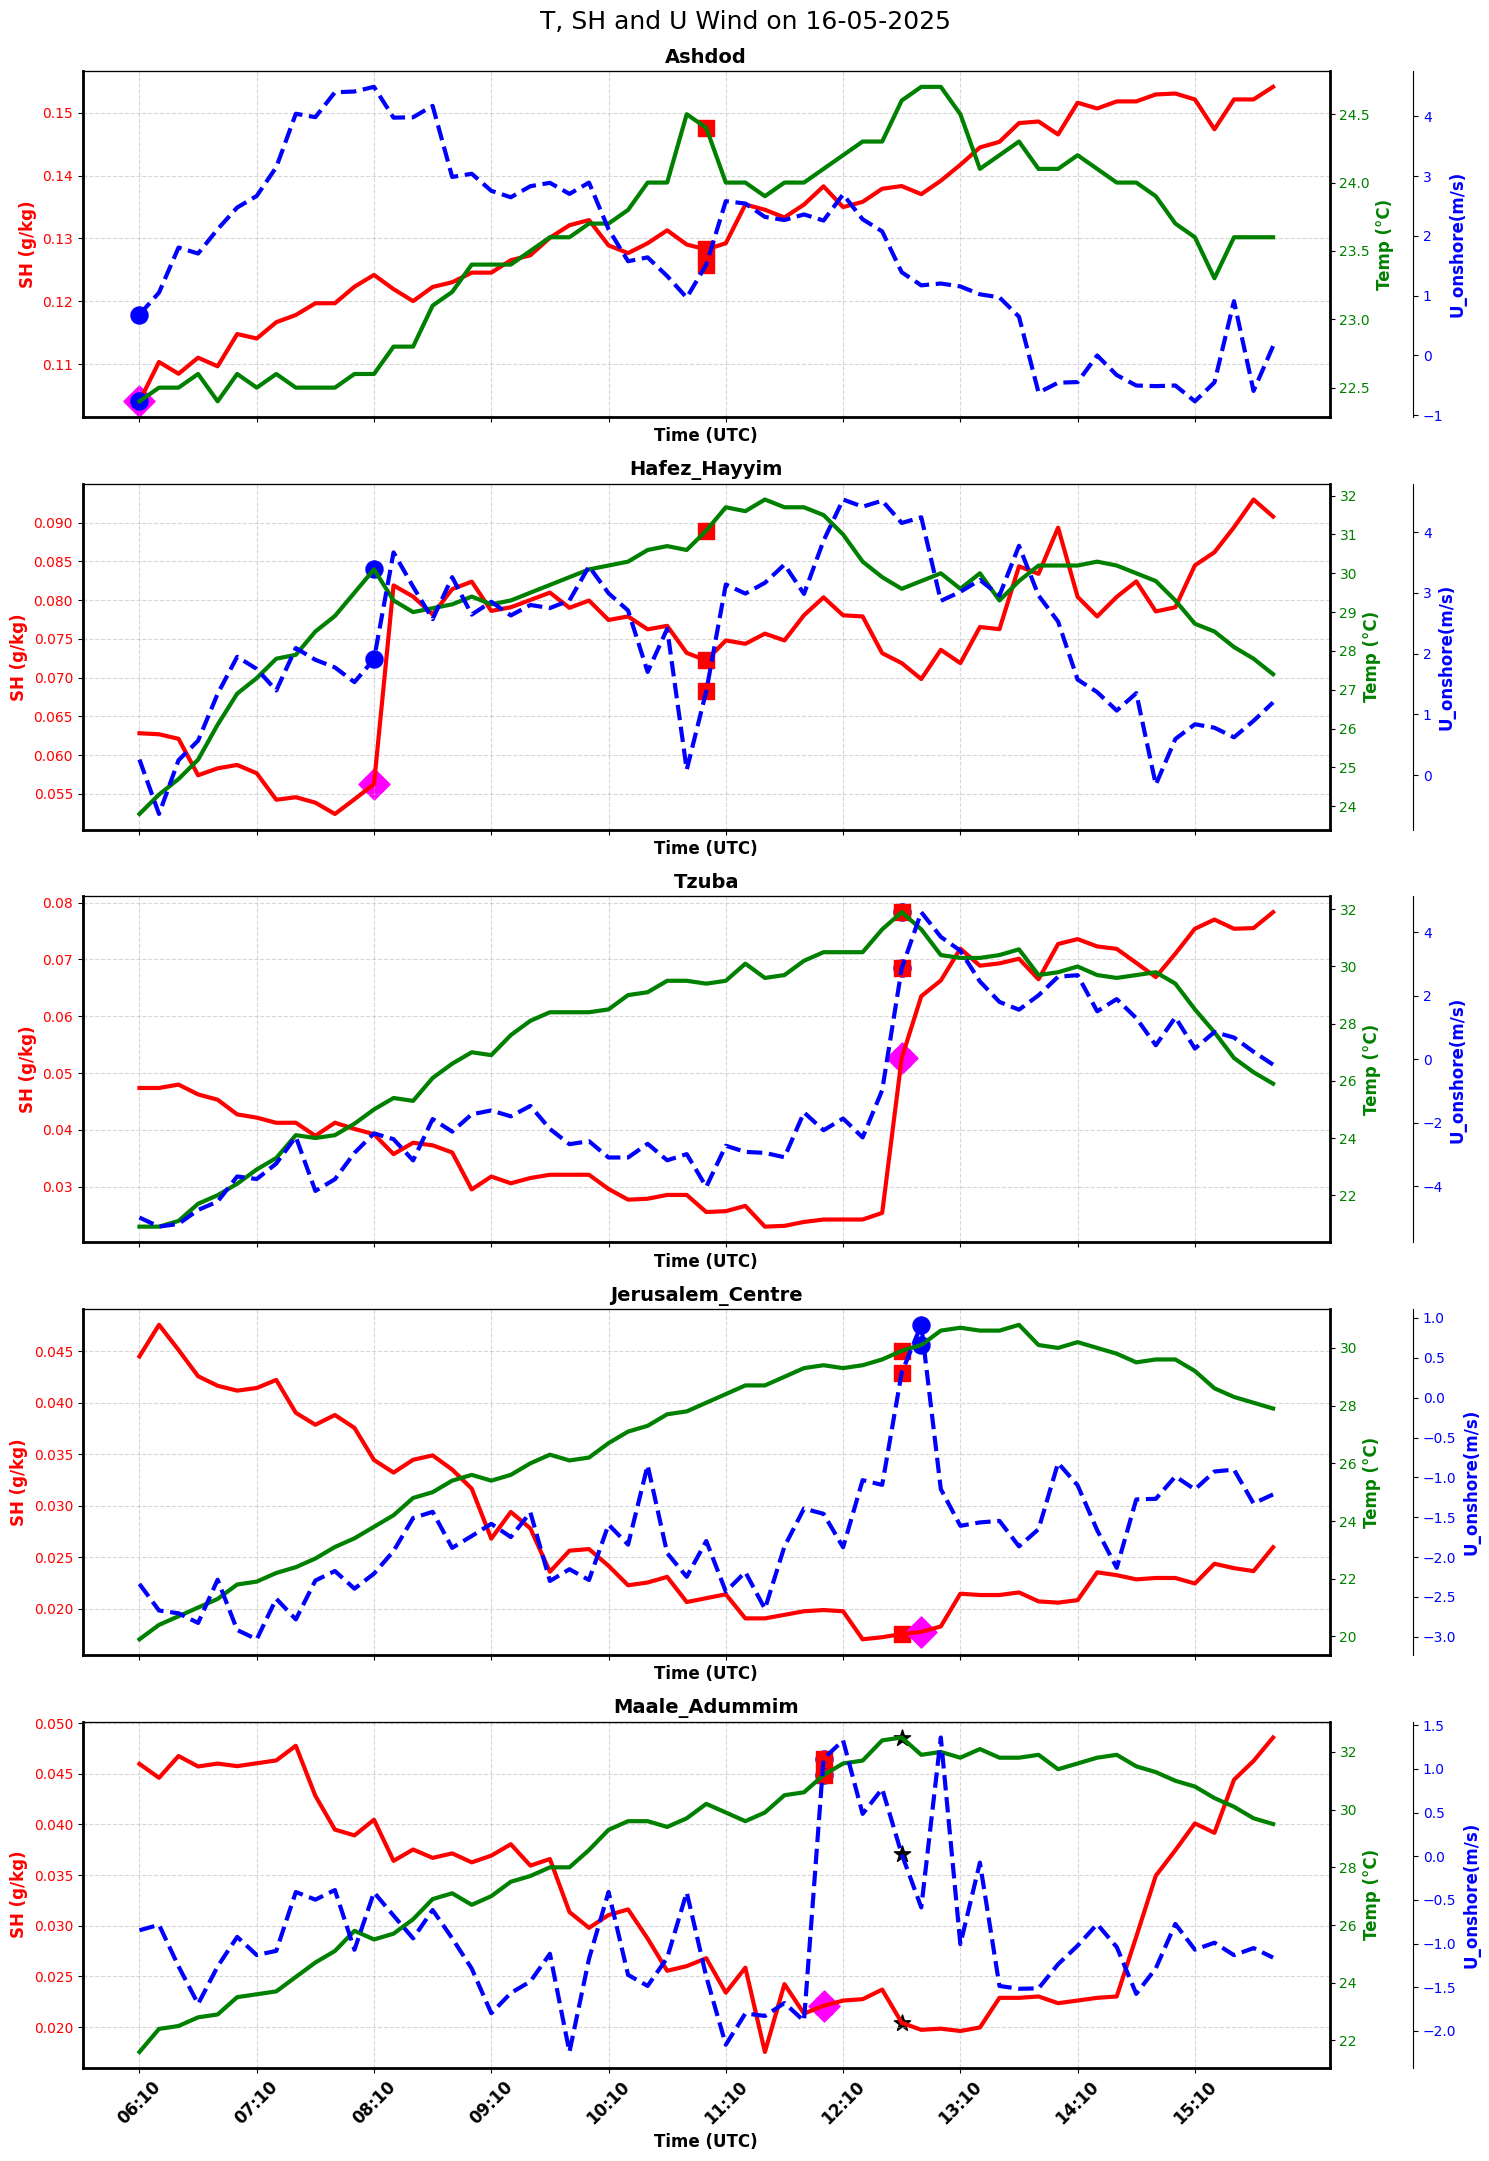

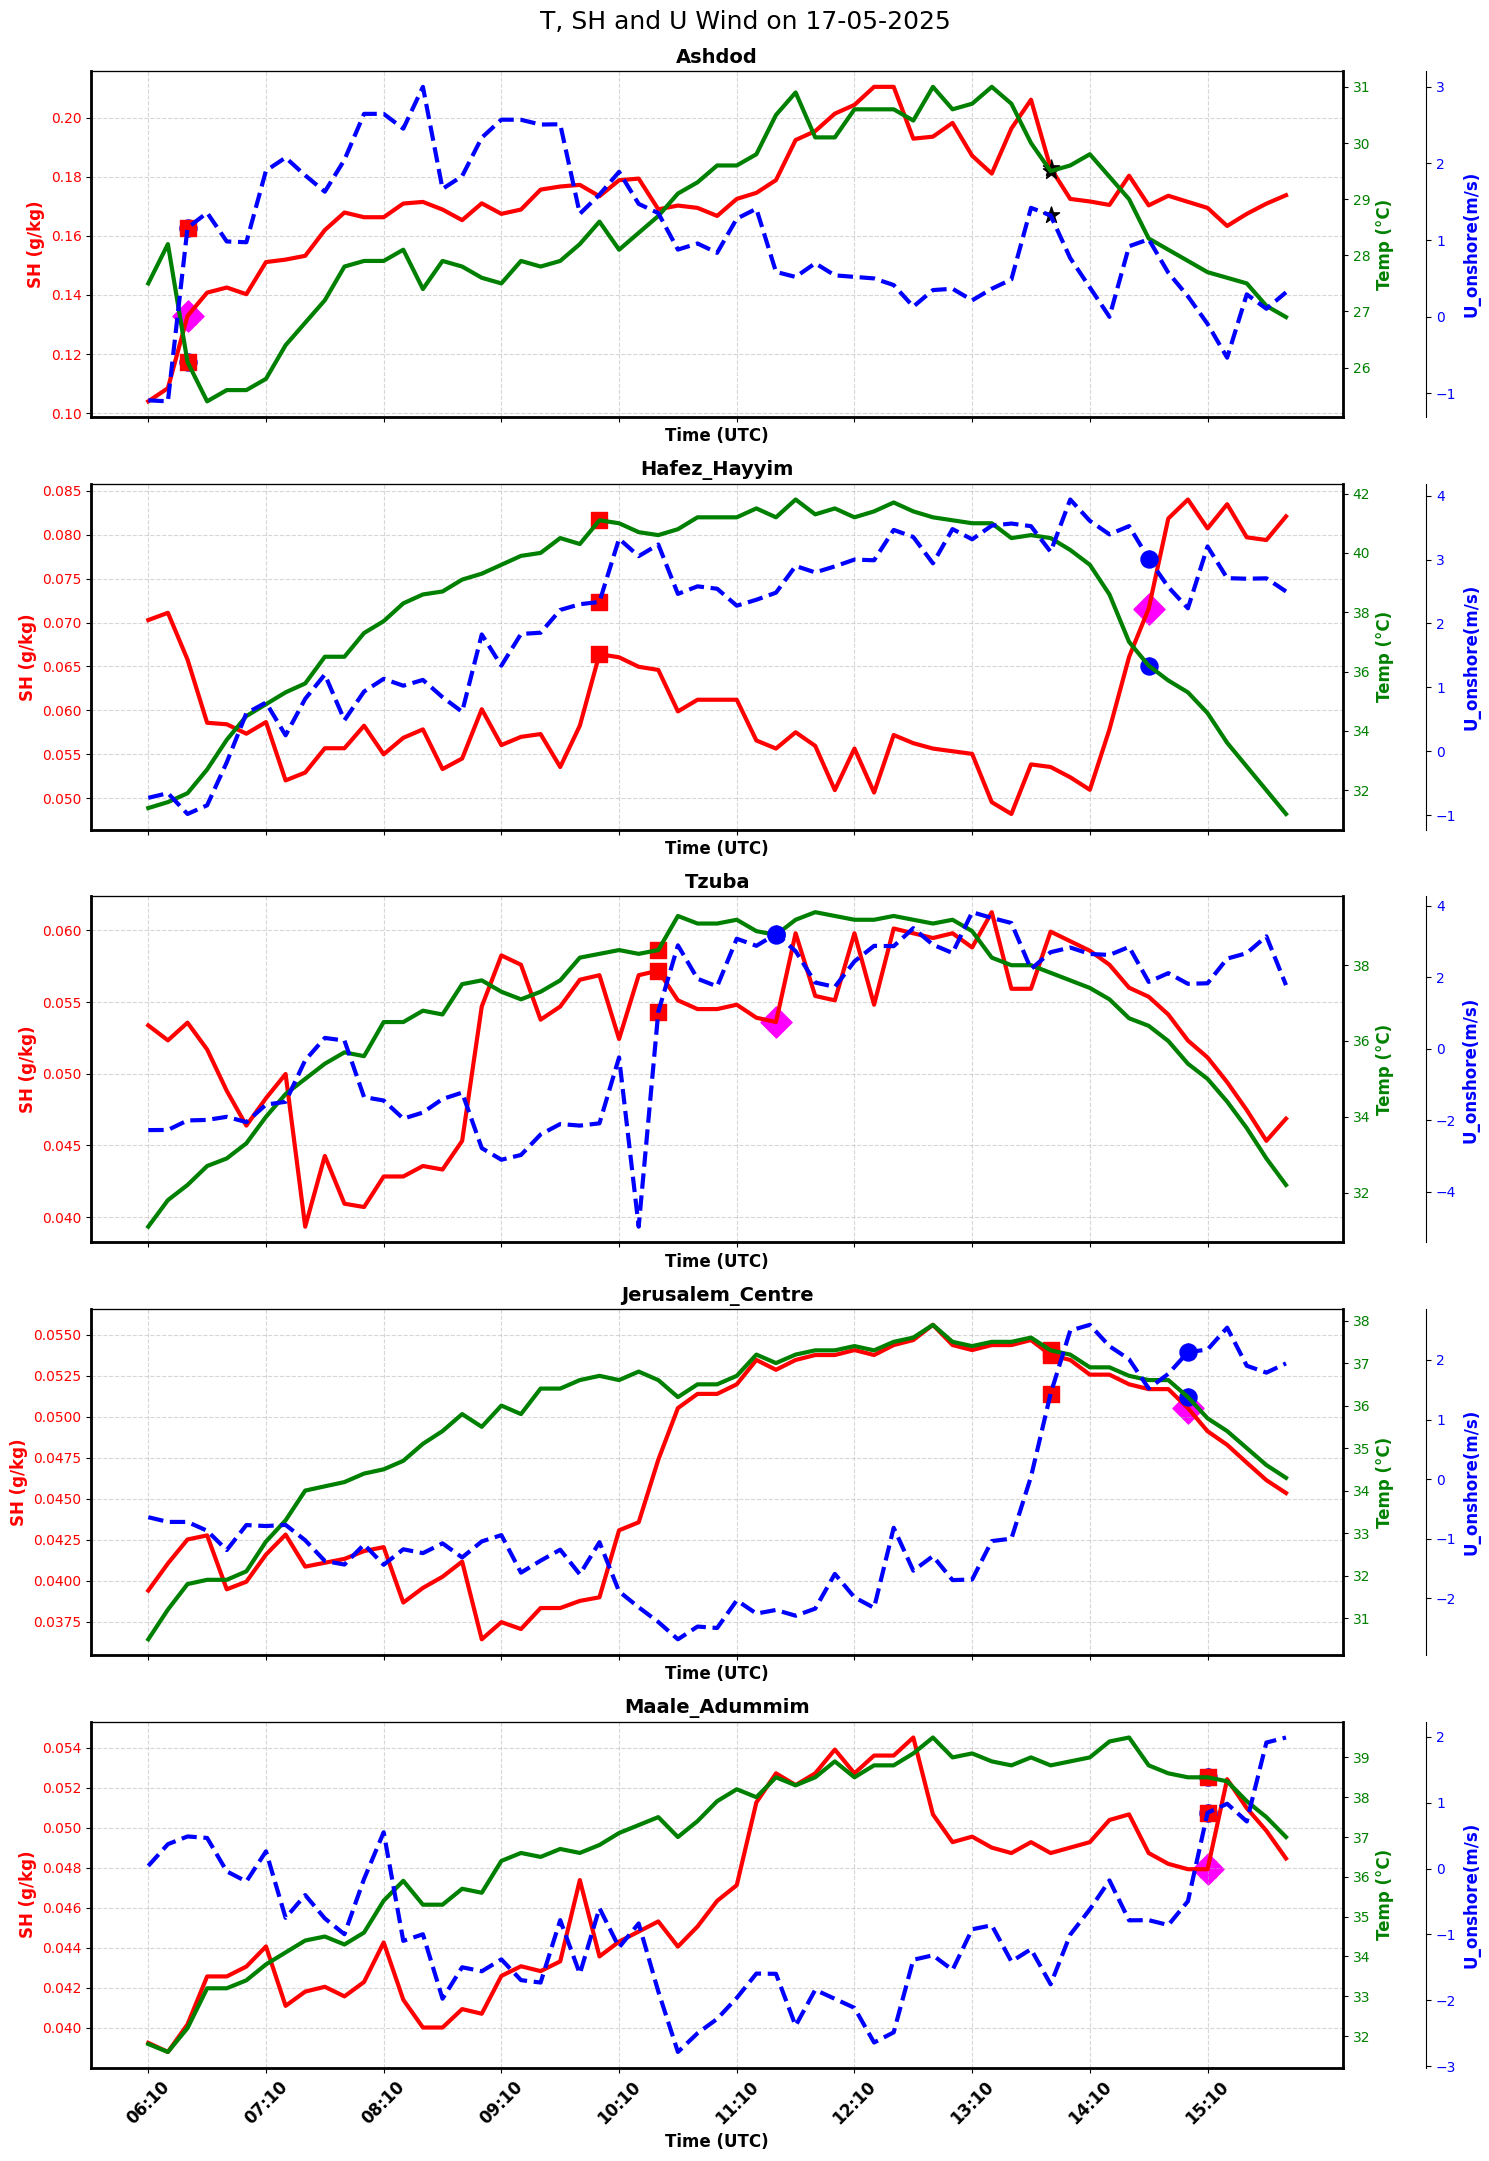

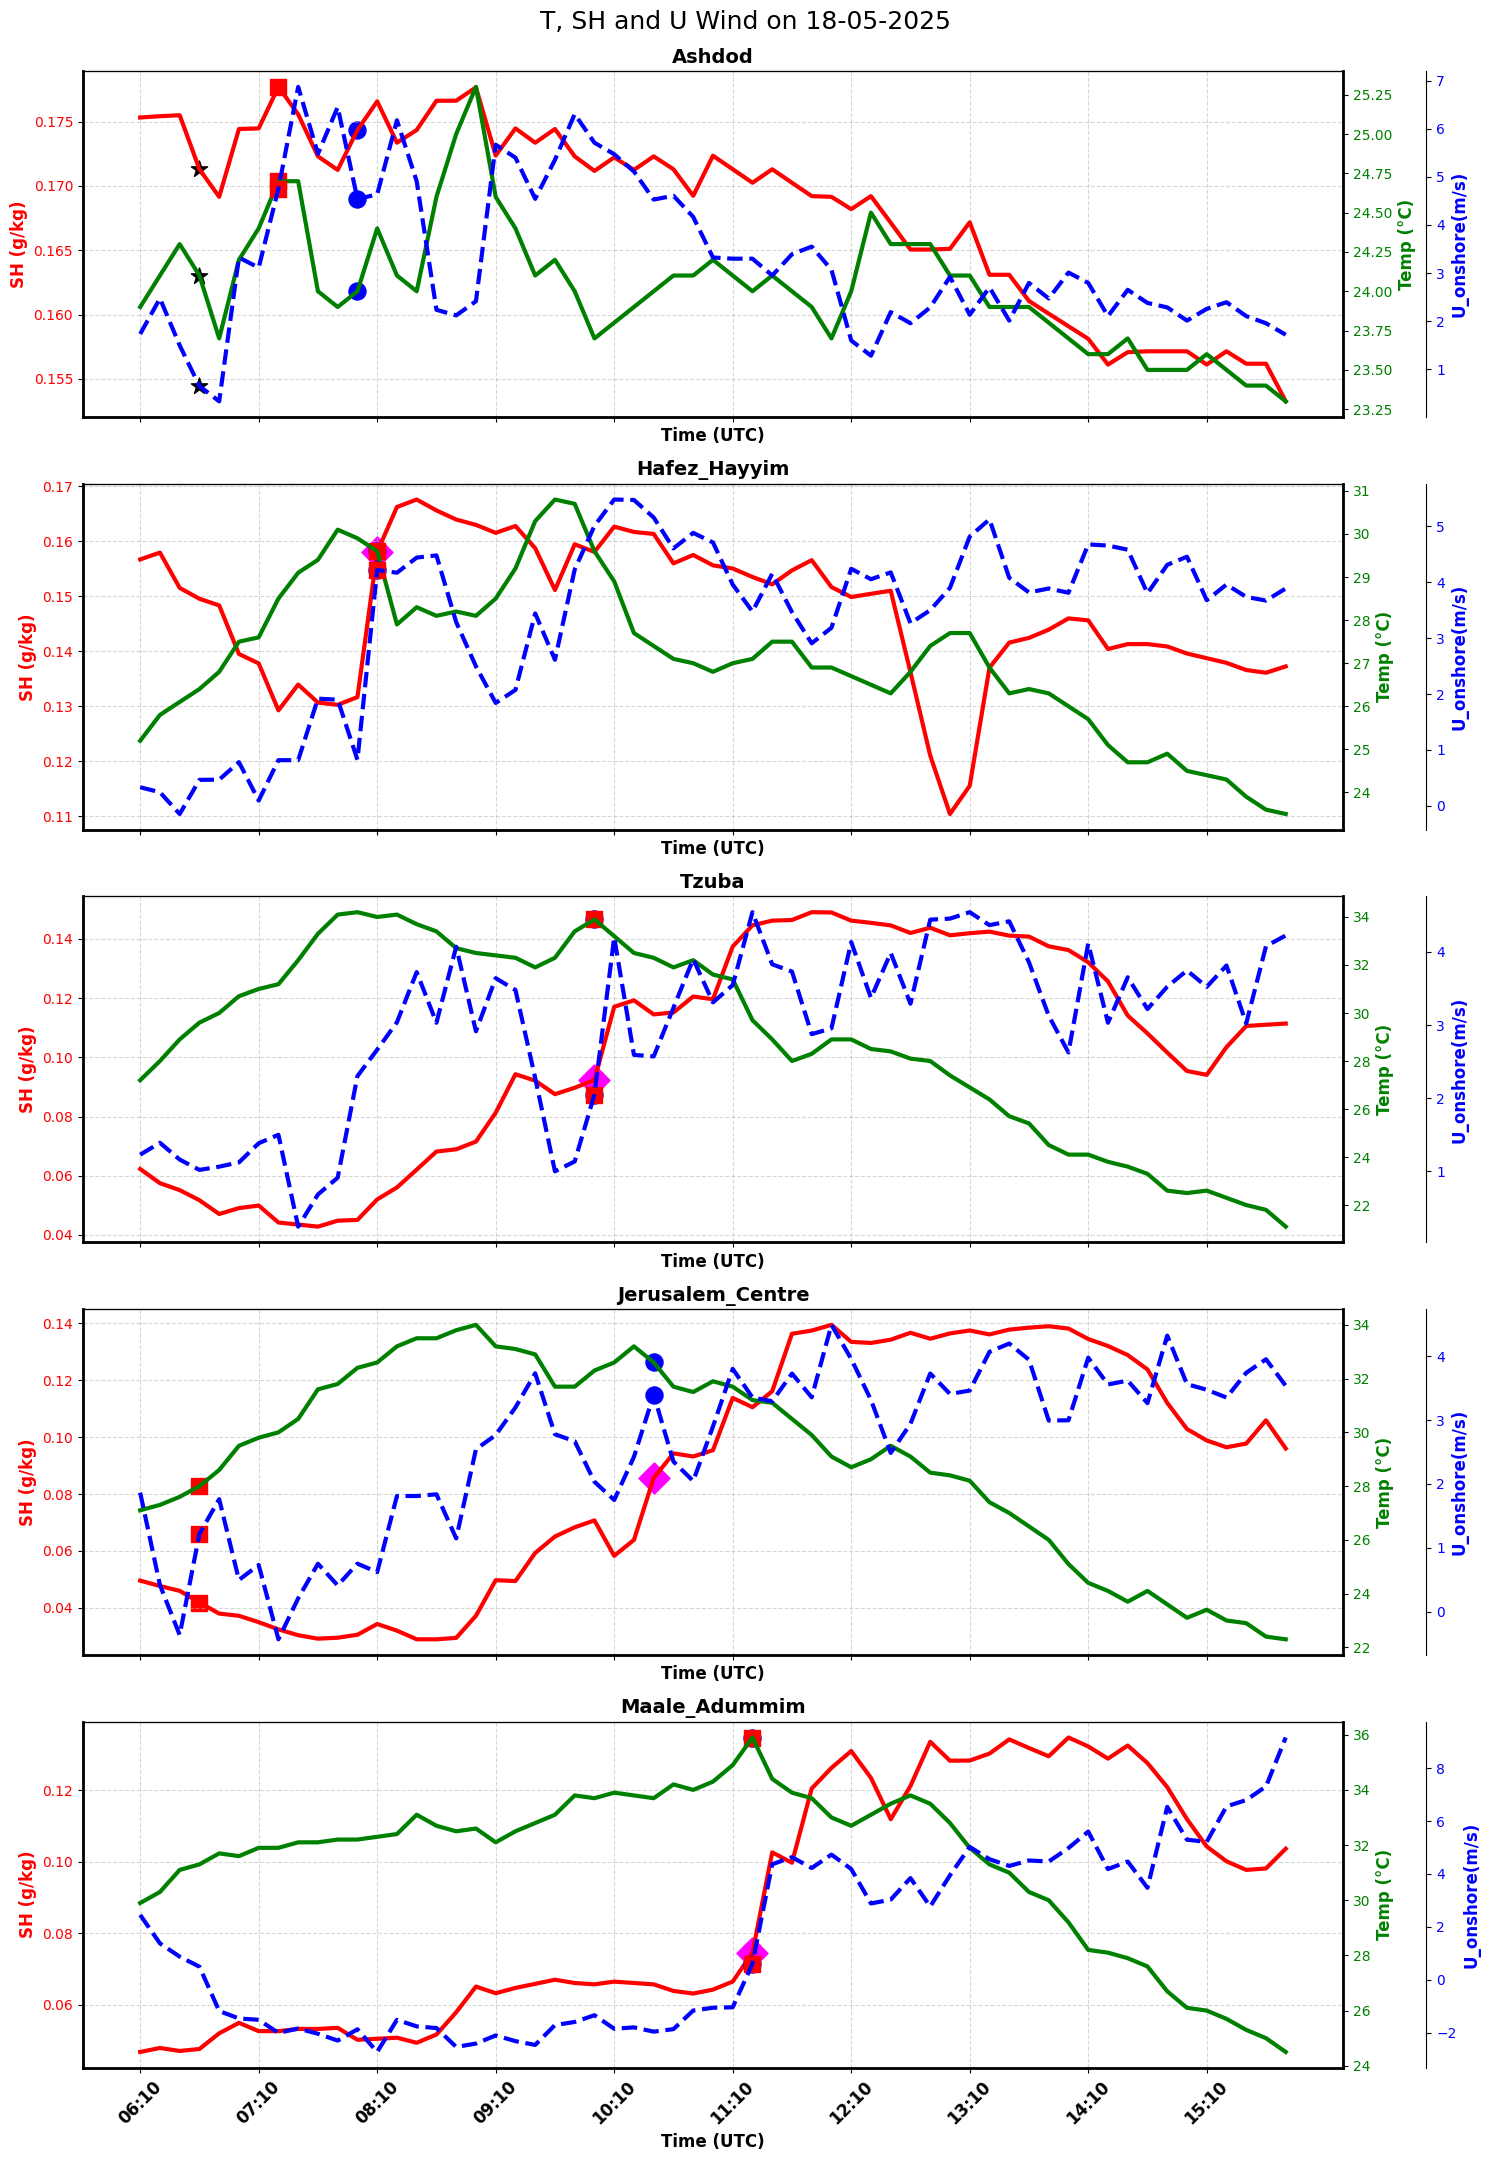

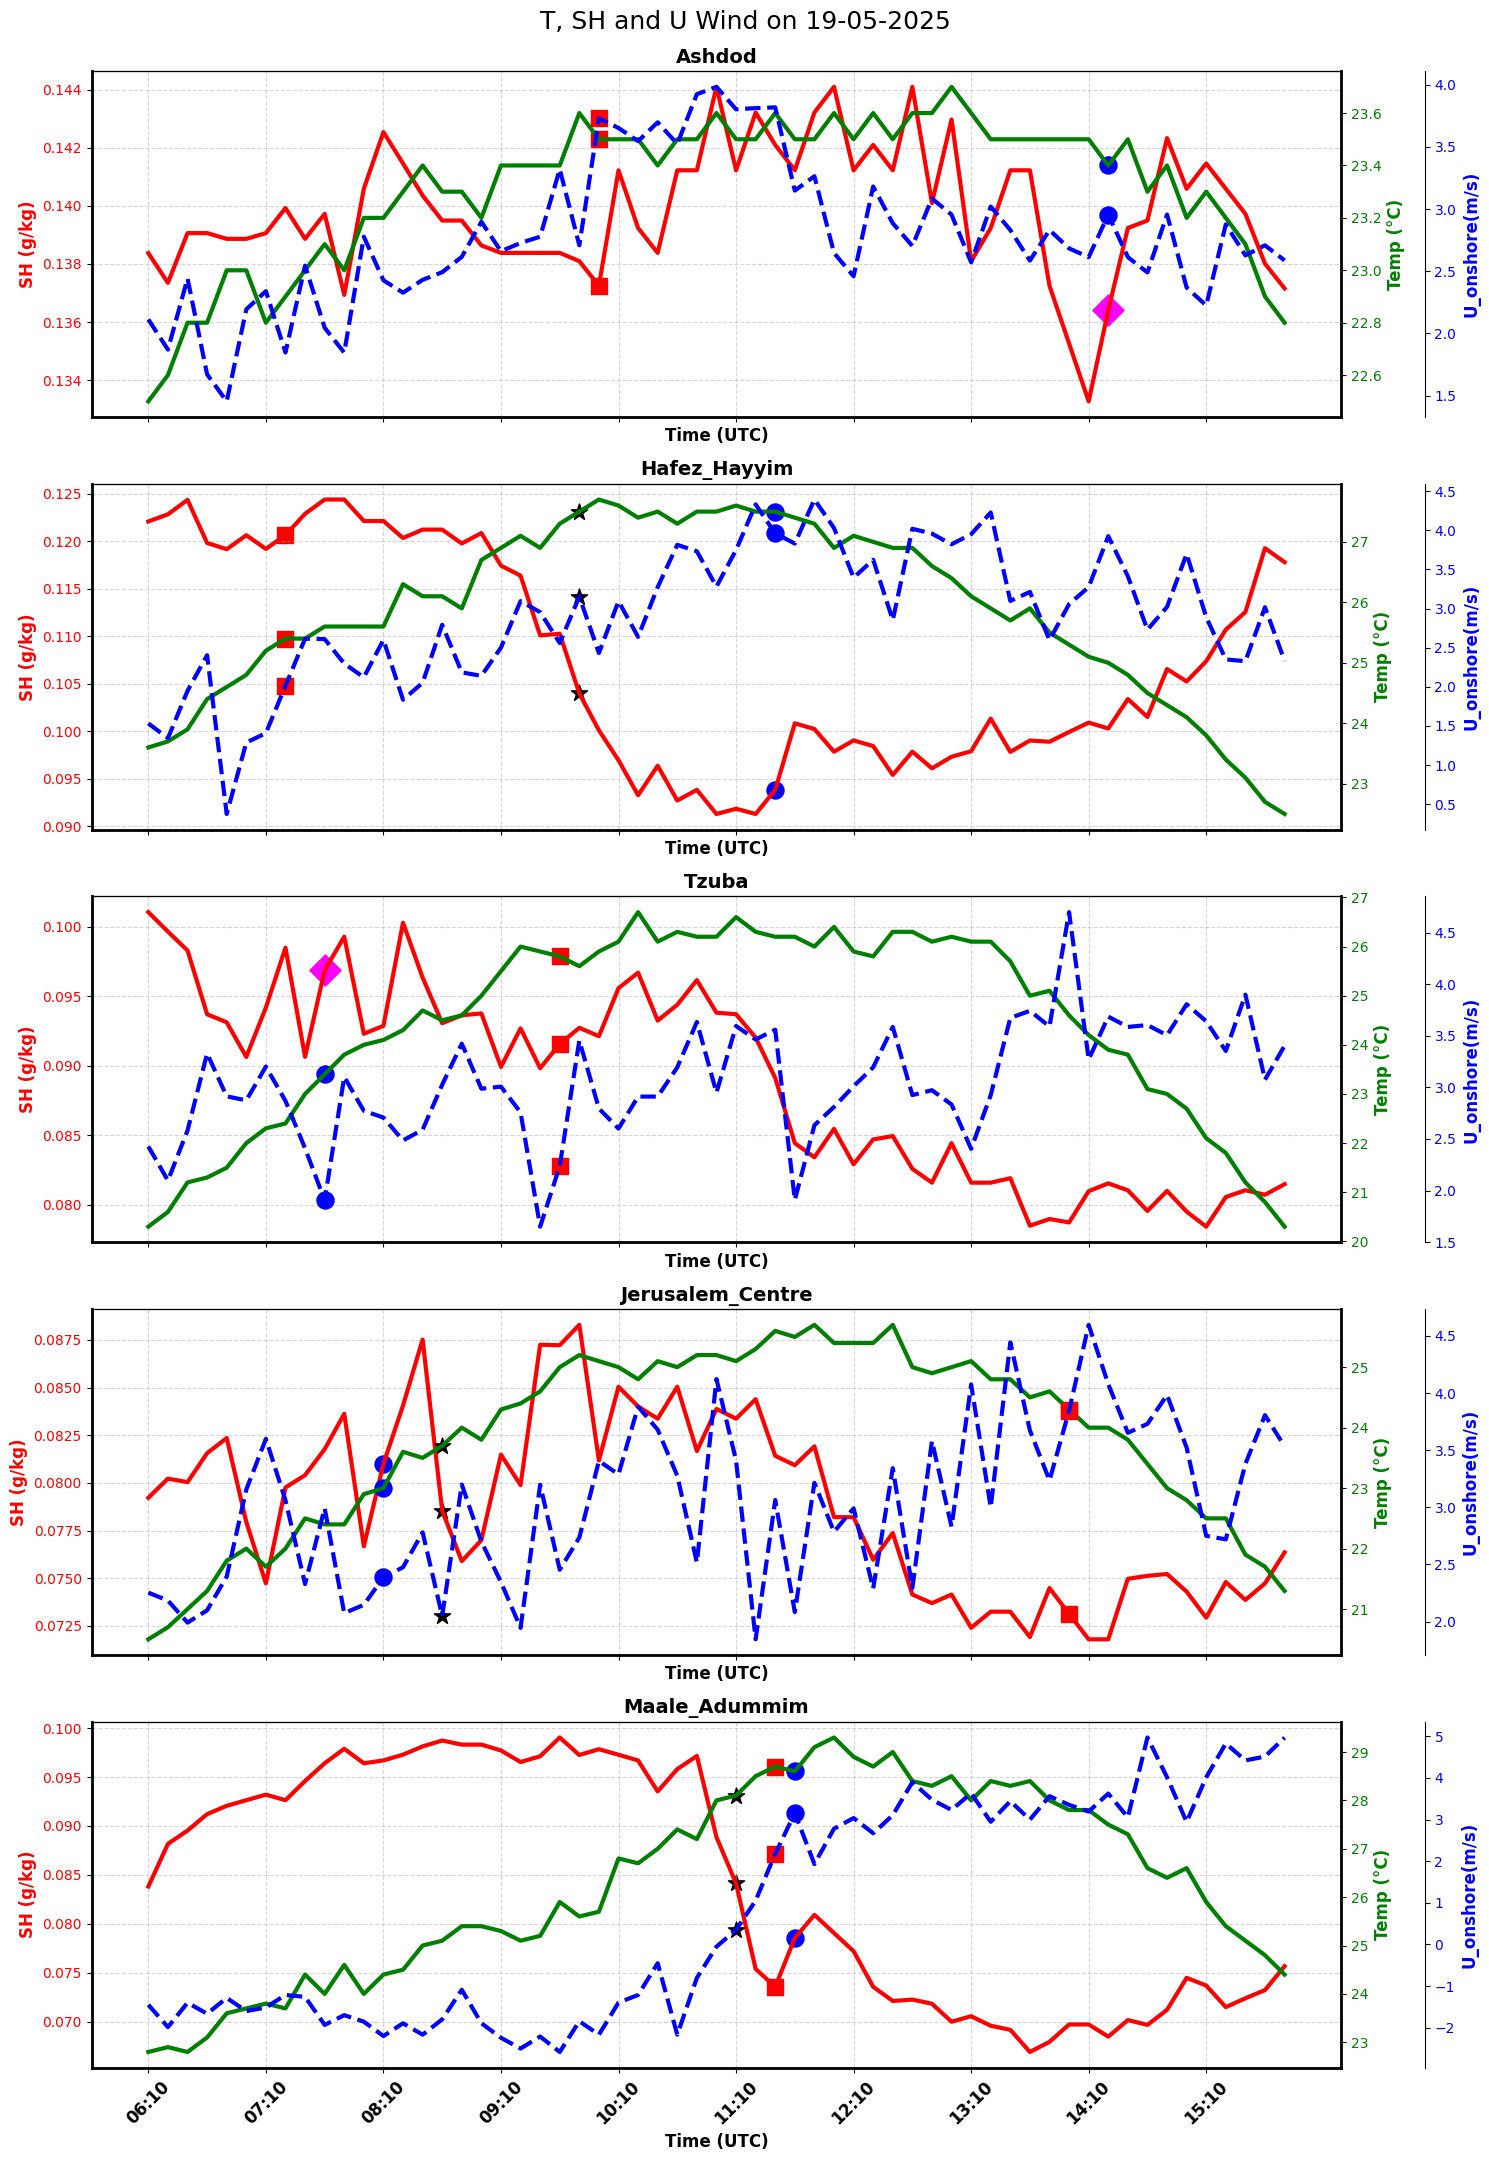

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3
def compute_sbf_trend(file_path, year, month, day):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()

    # Convert numeric columns
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DATE
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)

    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15

    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"] / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE FUNCTION
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([
                values[i - 1],
                values[i],
                values[i + 1]
            ])

            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)
        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    t1 = (
        df.loc[
            mask_u_positive,
            "q_3point_slope"
        ]
        .abs()
        .idxmax()
    )

    mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))
    # t2 = (df.loc[mask_t2, "q_3point_slope"].idxmax())
    #mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))
    if mask_t2.any():
      t2 = df.loc[mask_t2, "q_3point_slope"].idxmax()
    else:
      t2 = t1

    t3 = (
        df.loc[
            mask_u_positive,
            "Vonshore_3point_slope"
        ]
        .idxmax()
    )

    # STORE FLAGS
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True

    return df


# FILES FOR 5 STATIONS
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# SELECT 7 CONSECUTIVE DAYS
dates = pd.date_range(start="2025-05-16", periods=4, freq="D")

# LOOP OVER DAYS
for current_date in dates:
    year = current_date.year
    month = current_date.month
    day = current_date.day

    # COMPUTE RESULTS
    results = {}
    for station, file in station_files.items():
        results[station] = compute_sbf_trend(file, year, month, day)

    # CREATE FIGURE
    fig, axes = plt.subplots(
        nrows=5,
        ncols=1,
        figsize=(15, 22),
        sharex=True
    )

    # PLOT ALL STATIONS
    for ax, (station, df) in zip(axes, results.items()):

        # Axis 1 → Specific Humidity
        ax.plot(df.index, df["q_gkg"], color="red", linewidth=3, label="Specific Humidity")
        ax.set_ylabel("SH (g/kg)", color="red", fontsize=12, fontweight='bold')
        ax.tick_params(axis='y', labelcolor="red")


        # Axis 2 → Temperature
        ax2 = ax.twinx()
        ax2.plot(df.index, df["Temperature (°C)"],
                 color="green", linewidth=3, label="Temperature")
        ax2.set_ylabel("Temp (°C)", color="green", fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor="green")

        # Axis 3 → Onshore Wind
        ax3 = ax.twinx()
        ax3.spines["right"].set_position(
            ("outward", 60)
        )

        ax3.plot(
            df.index,
            df["V_onshore"],
            color="blue",
            linestyle="--",
            linewidth=3,
            label="Onshore Wind"
        )

        ax3.set_ylabel("U_onshore(m/s)", color="blue", fontsize=12, fontweight='bold')
        ax3.tick_params(axis='y', labelcolor="blue")

        # t1 markers
        t1_row = df[df["t1"]]
        ax.scatter(
            t1_row.index,
            t1_row["q_gkg"],
            marker="*",
            s=150,
            color="black"
        )

        ax2.scatter(
            t1_row.index,
            t1_row["Temperature (°C)"],
            marker="*",
            s=150,
            color="black"
        )

        ax3.scatter(
            t1_row.index,
            t1_row["V_onshore"],
            marker="*",
            s=150,
            color="black"
        )

        # t2 markers
        t2_row = df[df["t2"]]
        ax.scatter(
            t2_row.index,
            t2_row["q_gkg"],
            marker="o",
            s=150,
            color="blue"
        )

        ax2.scatter(
            t2_row.index,
            t2_row["Temperature (°C)"],
            marker="o",
            s=150,
            color="blue"
        )

        ax3.scatter(
            t2_row.index,
            t2_row["V_onshore"],
            marker="o",
            s=150,
            color="blue"
        )

        # t3 markers
        t3_row = df[df["t3"]]
        ax.scatter(
            t3_row.index,
            t3_row["q_gkg"],
            marker="s",
            s=120,
            color="red"
        )

        ax2.scatter(
            t3_row.index,
            t3_row["Temperature (°C)"],
            marker="s",
            s=120,
            color="red"
        )

        ax3.scatter(
            t3_row.index,
            t3_row["V_onshore"],
            marker="s",
            s=120,
            color="red"
        )

        # Overlap points
        df["overlap_count"] = (
            df[["t1", "t2", "t3"]]
            .sum(axis=1)
        )

        overlap = df[df["overlap_count"] > 1]

        ax.scatter(
            overlap.index,
            overlap["q_gkg"],
            marker="D",
            color="magenta",
            s=250
        )

        # X-axis formatting
        ax.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
        ax.set_xticks(df.index[::6])
        ax.set_xticklabels(df.index[::6].strftime("%H:%M"),
                           rotation=45, fontsize= 12, fontweight='bold')
        # Formatting
        ax.set_title(station, fontsize=14, fontweight="bold")

        ax.grid(
            True,
            linestyle="--",
            alpha=0.5
        )

        # To increase axis length
        ax.spines["bottom"].set_linewidth(2)
        ax.spines["left"].set_linewidth(2)
        ax.spines["right"].set_linewidth(2)

        ax.set_xticks(df.index[::6])
        ax.set_xticklabels(df.index[::6].strftime("%H:%M"), rotation=45)

    # FIGURE TITLE
    fig.suptitle(
        f"T, SH and U Wind on {day:02d}-{month:02d}-{year}\n",
        fontsize=18
    )
    plt.tight_layout()

    # SAVE FIGURE
    plt.savefig(
        f"All_Stations_SBF_{year}_{month:02d}_{day:02d}.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()